# CREATE HULL OF FIRST CONNECTED COMPOSANT OF NETKDE RESULT BY TOPONYM

    # LOAD PACKAGES AND LIB

In [1]:
import pandas as pd 
import geopandas as gpd
import pickle 
import fiona
from collections import OrderedDict
from pyproj import Transformer
from geopandas import GeoDataFrame
from shapely.geometry import Point
import networkx as nx
import osmnx as ox
import shapely
import matplotlib.pyplot as plt
import shapefile
from shapely.geometry import MultiLineString, MultiPolygon
from shapely.ops import linemerge
import networkx as nx 

import shapely.speedups
shapely.speedups.enable()
import momepy
import ogr 
import json

c:\users\ablanchi\appdata\local\programs\python\python36\lib\site-packages\geopandas\_compat.py:110: UserWarning: The Shapely GEOS version (3.8.0-CAPI-1.13.1 ) is incompatible with the GEOS version PyGEOS was compiled with (3.10.1-CAPI-1.16.0). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [2]:
def dilatation_of_3(G, subgraph):
    subgraph_node_indices = list(subgraph.nodes())

    all_neighbors = []
    for node_index in subgraph_node_indices:
            neighbors = nx.all_neighbors(G, node_index)
            all_neighbors.extend(neighbors)

    all_neighbors2 = []       
    for node_index in all_neighbors:
            neighbors = nx.all_neighbors(G, node_index)
            all_neighbors2.extend(neighbors)

    all_neighbors3 = []        
    for node_index in all_neighbors2:
            neighbors = nx.all_neighbors(G, node_index)
            all_neighbors3.extend(neighbors)
    
    al_node_dilat = all_neighbors3 + all_neighbors2 + all_neighbors 
    A = set(al_node_dilat)
    
    subgraph_dilated = G.subgraph(A)
    subgraph_dilated = nx.Graph(subgraph_dilated)
    
    return subgraph_dilated

In [3]:
def erosion_of_3(G, subgraph_dilated):
    subgraph_dilated_node_indices = list(subgraph_dilated.nodes())
    G_node_indices = list(G.nodes())
    len(G_node_indices)
    
    G_node_erosion = []

    for node in G_node_indices:
        if node not in subgraph_dilated_node_indices:
            G_node_erosion.append(node)
    
    ## Attention le pb c'est que finalement le noeud extrémité il le prend pour dilated et pas parmis les deux donc 3 = 4
    all_neighbors = []
    for node_index in G_node_erosion:
            neighbors = nx.all_neighbors(G, node_index)
            all_neighbors.extend(neighbors)

    all_neighbors2 = []       
    for node_index in all_neighbors:
            neighbors = nx.all_neighbors(G, node_index)
            all_neighbors2.extend(neighbors)

    all_neighbors3 = []        
    for node_index in all_neighbors2:
            neighbors = nx.all_neighbors(G, node_index)
            all_neighbors3.extend(neighbors)
            
    all_neighbors4  = []   
    for node_index in all_neighbors3:  
        neighbors = nx.all_neighbors(G, node_index)
        all_neighbors4.extend(neighbors)
             
    al_node_erod = all_neighbors3 + all_neighbors2 + all_neighbors #+ all_neighbors4
    B = set(al_node_erod)
    
    nodes_dilerod = []
    for node in subgraph_dilated_node_indices:
        if node not in B:
            nodes_dilerod.append(node)
    
    nodes_dilerod = set(nodes_dilerod)
    
    subgraph_eroded = G.subgraph(nodes_dilerod)
    subgraph_eroded = nx.Graph(subgraph_eroded)
    
    return subgraph_eroded


    # IMPORT LIXELS FROM NETKDE RESULT 

In [4]:
VILLE = "NICE"

In [5]:
#pd.read_csv("C:/Users/ablanchi/Desktop/lixels_cannes_test_more_50.csv", delimiter=';')

df = pd.read_excel("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/LIXELS_NETKDE_POSITF.xlsx", engine='openpyxl')

In [6]:
#pd.read_csv("C:/Users/ablanchi/Desktop/lixels_cannes_test_more_50.csv", delimiter=';')

df = pd.read_excel("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/LIXELS_NETKDE_POSITF.xlsx", engine='openpyxl')
## IMPORT NETWORK OR LIXELS
streets = gpd.read_file("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/LIXELS_VILLE.shp")
streets = streets.to_crs("EPSG:2154")
lixels = streets[['lineID', 'uid', 'geometry']]


lixels1 = lixels.merge(df, on ="lineID")
gdf = GeoDataFrame(lixels1, crs="EPSG:2154", geometry=lixels1.geometry_x)


In [19]:
gdf.columns

Index(['lineID', 'uid_x', 'geometry_x', 'uid_y', 'troncon_de', 'troncon__1',
       'troncon__2', 'NOM_max', 'BONAPART', 'geometry_y', 'beaulieu mer',
       'cap ferrat', 'corne or', 'jean cap ferrat', 'monaco', 'villefranche',
       'vinaigrier', 'geometry'],
      dtype='object')

In [7]:
path = "C:/GIT/2022/TOPONOMASCAPE/VILLE/ALPES-MARITIMES/1_ADS_RELOCALIZED.pickle"
file = open(path, "rb")
ADS_AM = pickle.load(file)
file.close()

# APPLICATION 

    # COMPOSANTE CONNEXE
> 1. Sélectionner la première composante connexe:
- Pour chaque toponyme (chaque colonne du df lixels): 
- Prendre les lixels > 0 
- Appliquer les composantes connexes 
- Extraire la première composante connexe
- Pour chaque lixel qui n'appartient pas à la première CC : 0) sinon lixel$toponym : result. 
-----------> Output : Nouveu Lixels .csv POSITIF

    # PHENOMENE POSITIF (GDF _LIXELS _ POSITIF)

In [8]:
notcol = ('lineID', 'uid_x', 'troncon_de_x', 'geometry_x', 'uid_y',
       'troncon_de_y', 'troncon__1', 'troncon__2', 'troncon__3', 'NOM_count',
       'NOM_unique', 'NOM_empty', 'NOM_filled', 'NOM_min', 'NOM_max',
       'NOM_min_le', 'NOM_max_le', 'NOM_mean_l', 'geometry_y', "uid", 'lineID', 'uid_x', 'trncn_d', 'geometry_x', 'uid_y', 'troncon_de',
       'troncon__1', 'troncon__2', 'troncon__3', 'geometry_y', 'geometry',
         'BONAPART')

In [9]:
# CREATE GRAPH G
G_VILLE = momepy.gdf_to_nx(gdf, approach='primal')

acropolis
longueur 1108
in cc 961


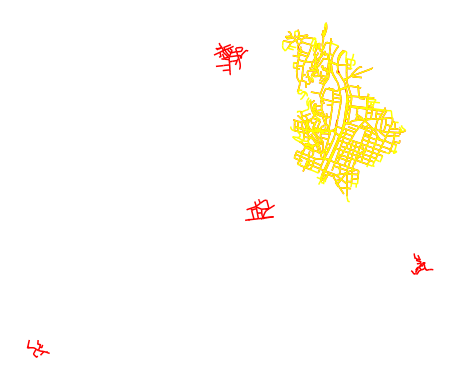

alban
longueur 2128
in cc 1401


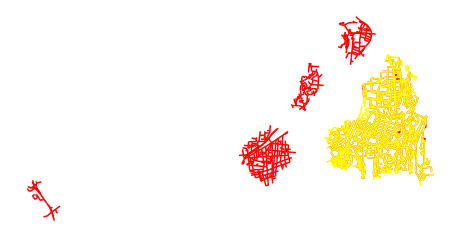

alphonse karr
longueur 258
in cc 245


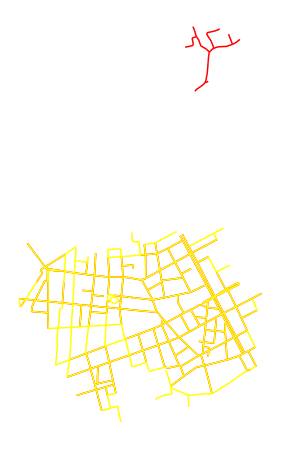

andrioli
longueur 216
in cc 209


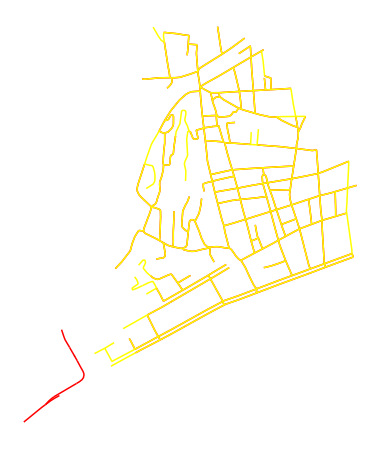

anglais
longueur 2754
in cc 2284


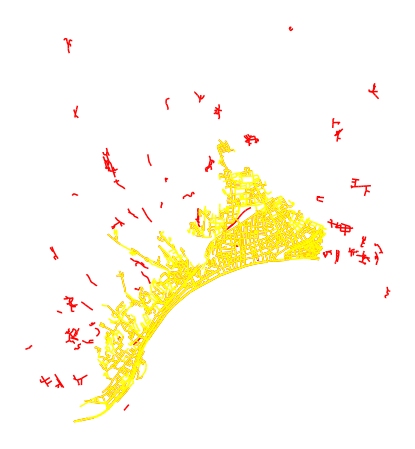

antiquaires
longueur 328
in cc 317


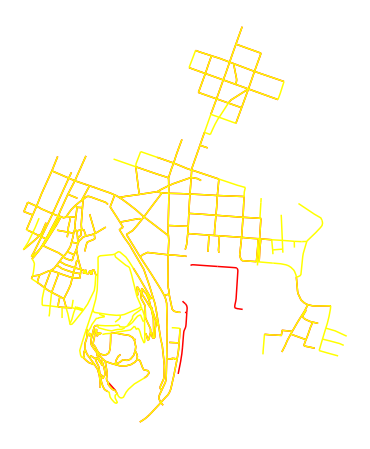

antoine
longueur 1881
in cc 1399


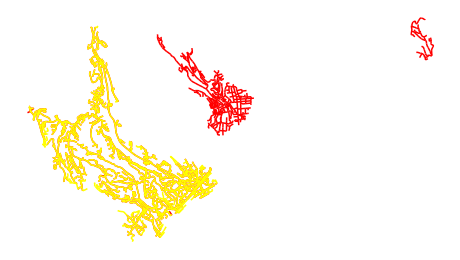

antoine ginestiere
longueur 485
in cc 396


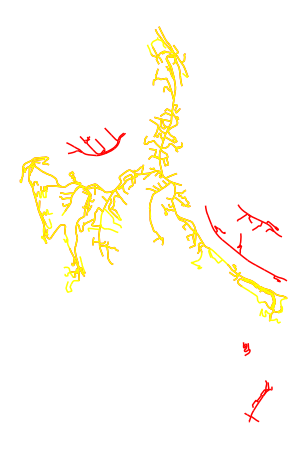

archet
longueur 1358
in cc 1134


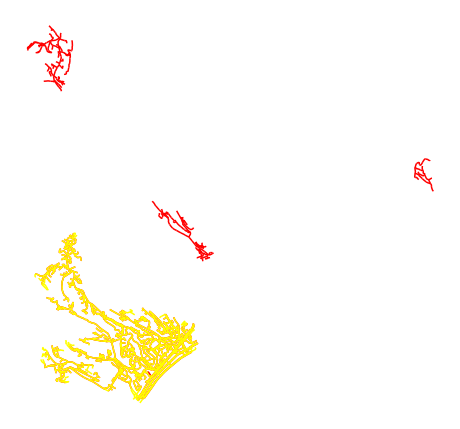

arenas
longueur 702
in cc 471


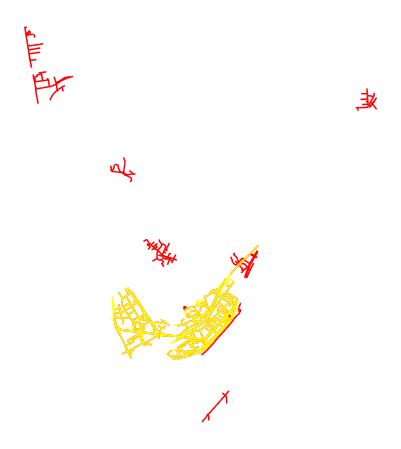

arenes
longueur 524
in cc 503


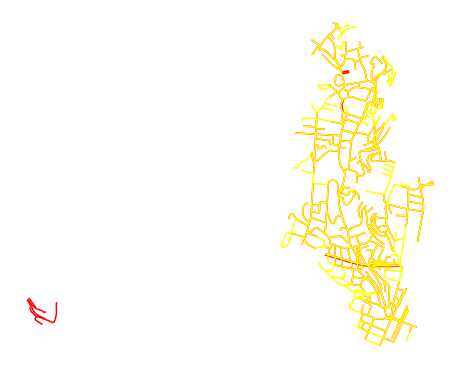

ariane
longueur 149
in cc 138


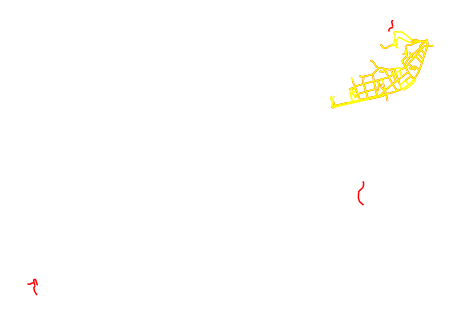

arson
longueur 826
in cc 369


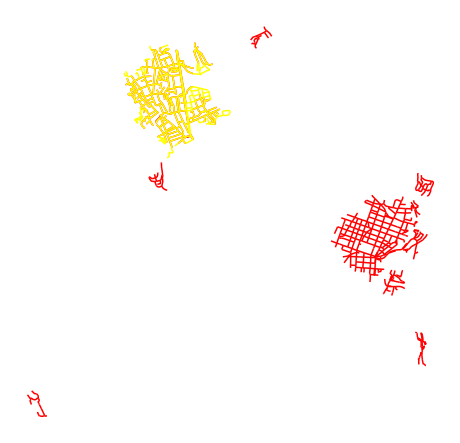

augustin
longueur 1388
in cc 944


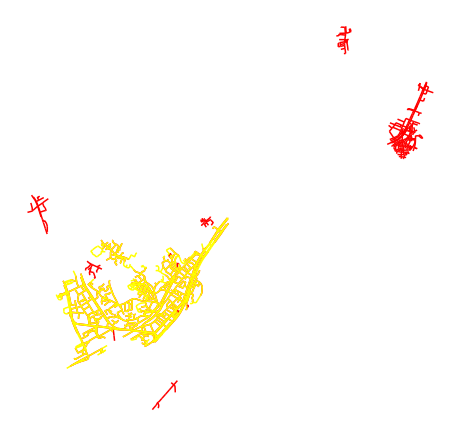

baie anges
longueur 8284
in cc 4730


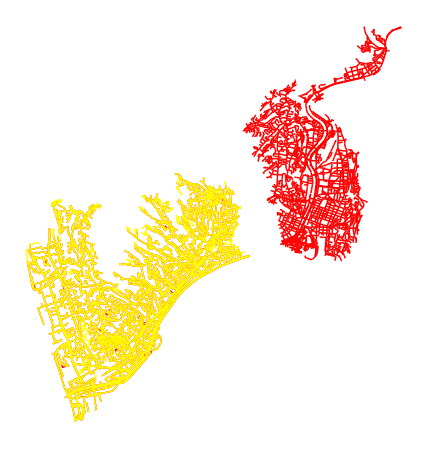

barberis
longueur 99
in cc 98


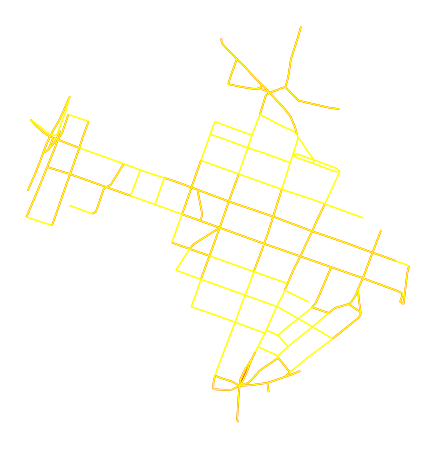

barla
longueur 530
in cc 417


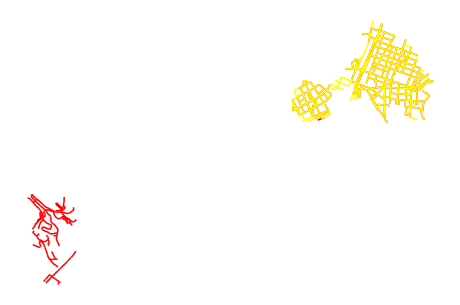

barthelemy
longueur 438
in cc 364


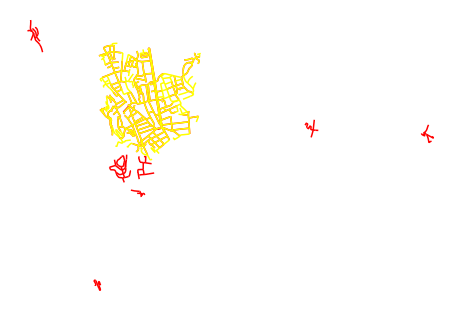

baumettes
longueur 1050
in cc 925


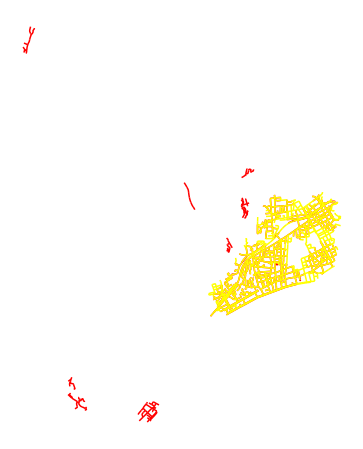

bellet
longueur 1326
in cc 1007


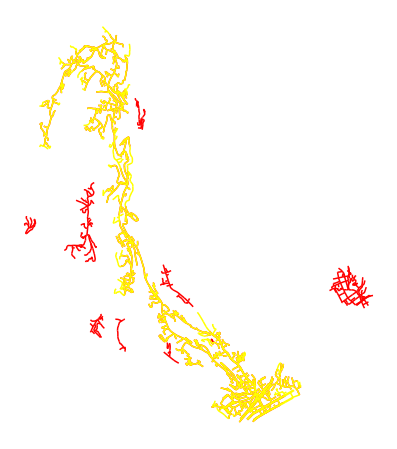

bellevue
longueur 854
in cc 566


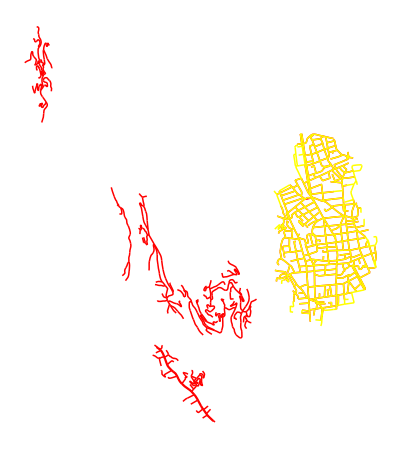

berlioz
longueur 110
in cc 109


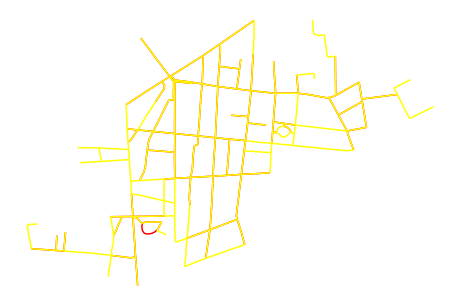

besset
longueur 362
in cc 320


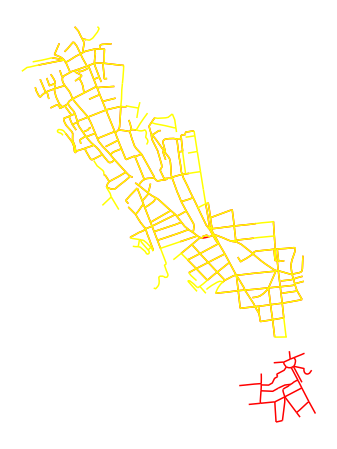

blue pearl
longueur 422
in cc 367


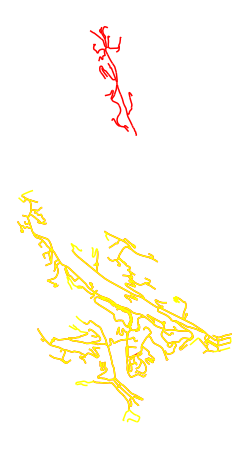

bonaparte
longueur 389
in cc 381


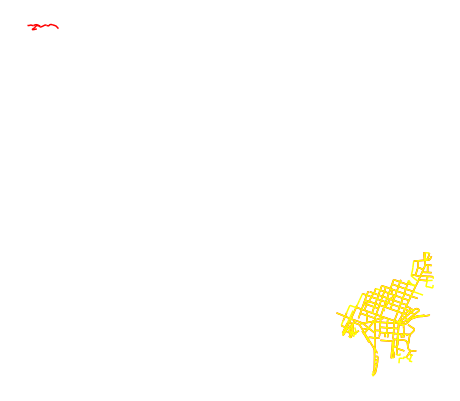

bornala
longueur 146
in cc 134


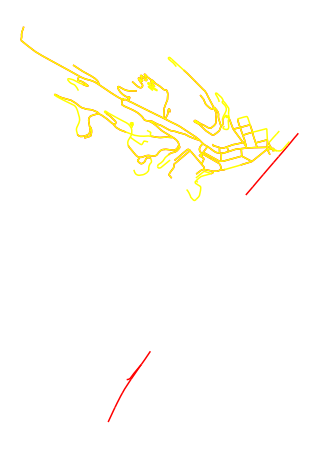

boron
longueur 1284
in cc 861


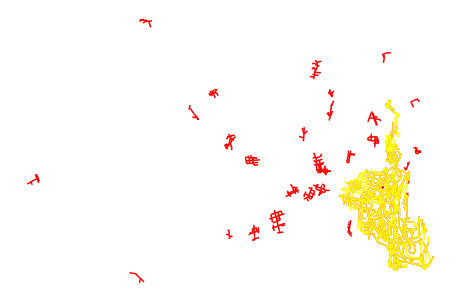

borriglione
longueur 521
in cc 412


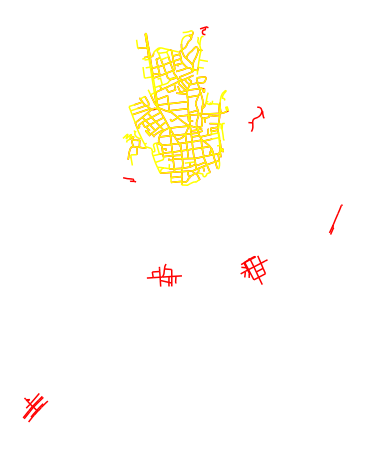

bottero
longueur 329
in cc 313


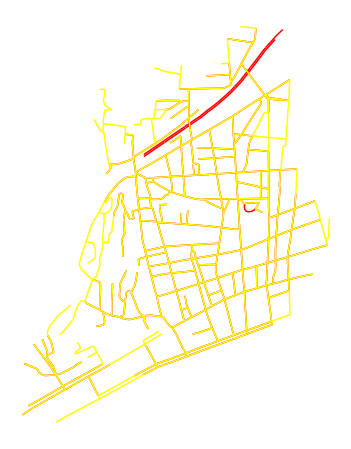

brancolar
longueur 297
in cc 251


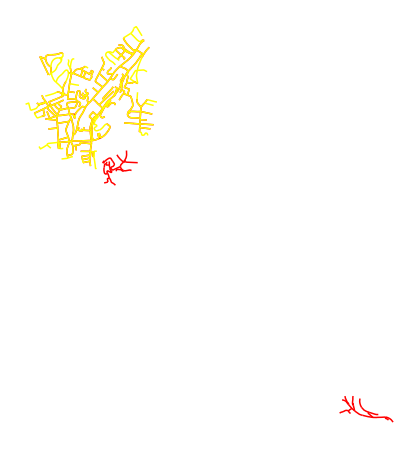

californie
longueur 495
in cc 407


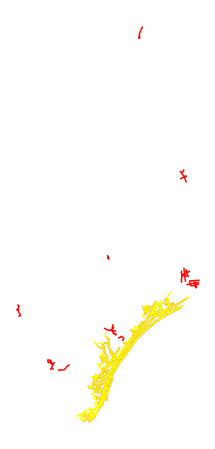

cap antibes
longueur 4677
in cc 2502


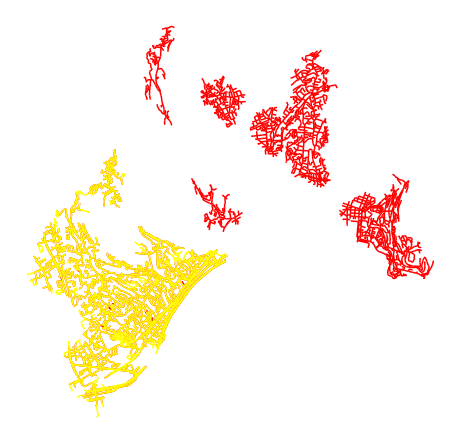

cap croix
longueur 719
in cc 287


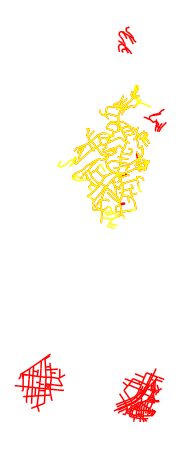

cap ferrat
longueur 1960
in cc 1720


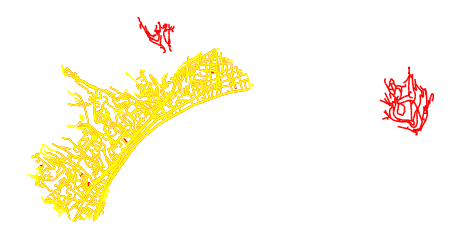

cap nice
longueur 312
in cc 239


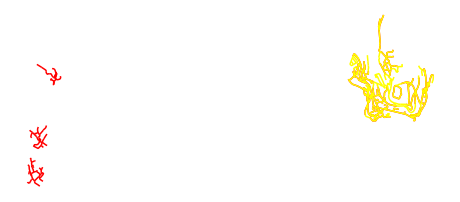

carabacel
longueur 322
in cc 306


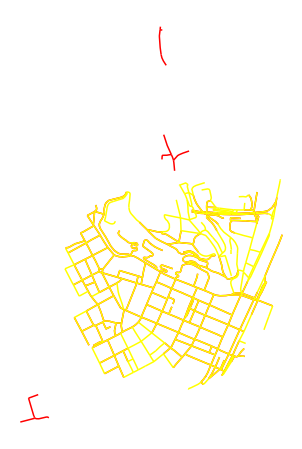

carlone
longueur 983
in cc 487


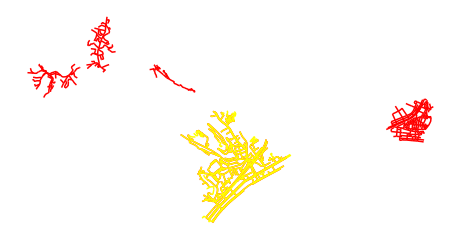

carras
longueur 507
in cc 449


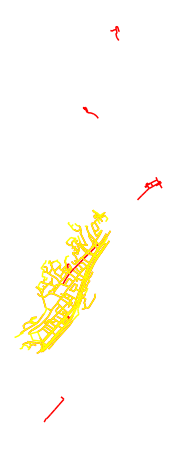

carre or
longueur 558
in cc 533


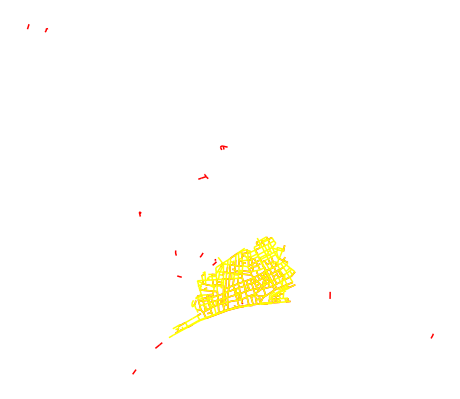

cassini
longueur 96
in cc 76


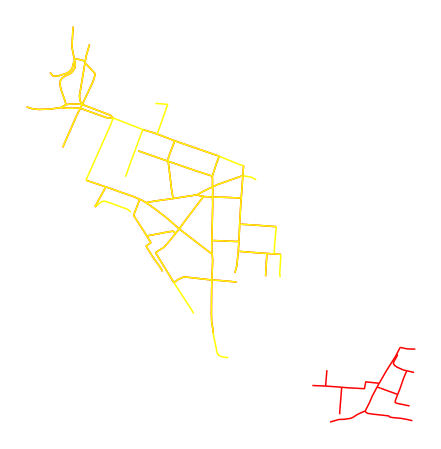

caucade
longueur 649
in cc 583


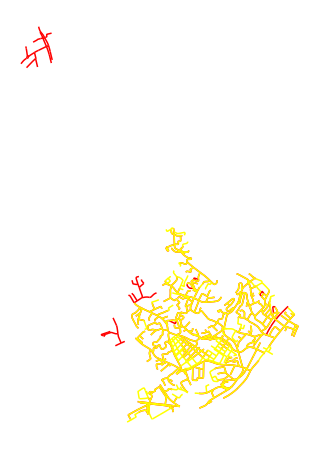

cessole
longueur 500
in cc 427


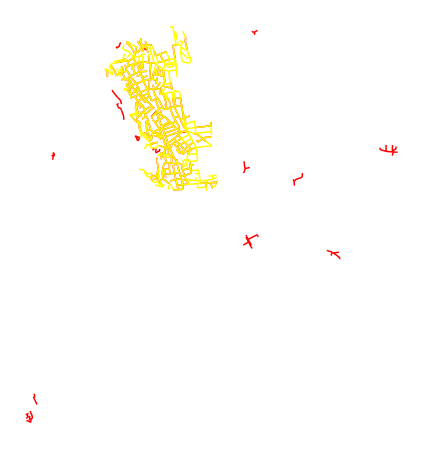

chambrun
longueur 459
in cc 353


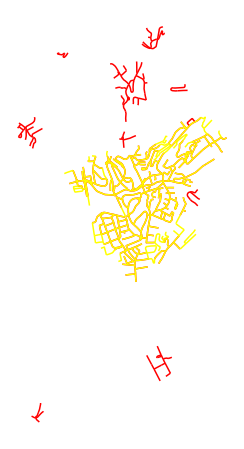

chateau
longueur 3494
in cc 2515


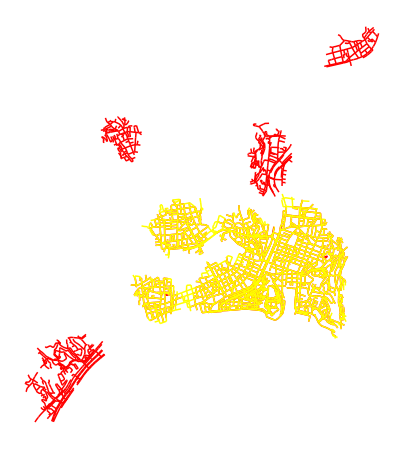

chateauneuf
longueur 68
in cc 57


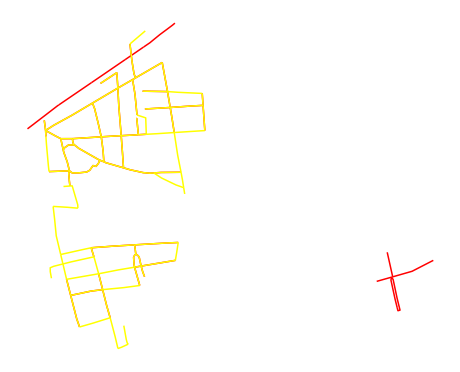

cimiez
longueur 1553
in cc 1335


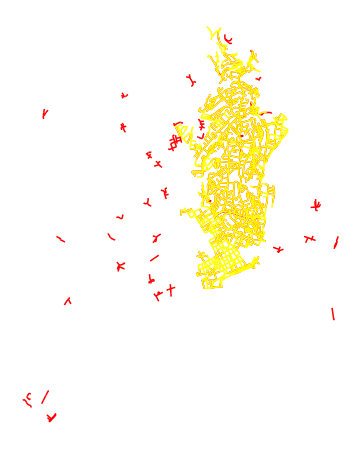

clemenceau
longueur 241
in cc 174


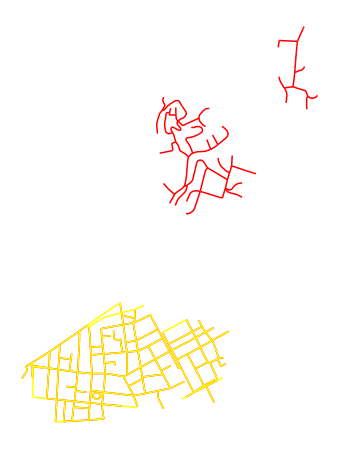

collines
longueur 3500
in cc 2578


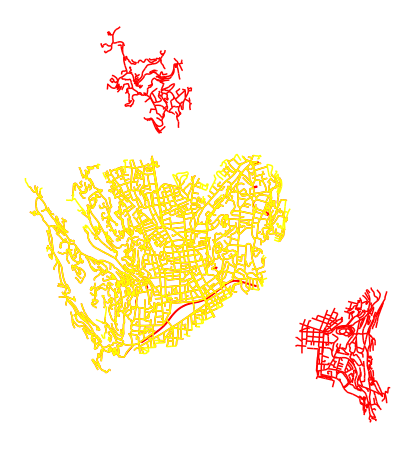

costiere
longueur 320
in cc 300


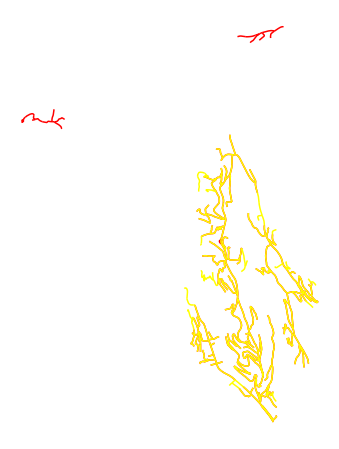

cours saleya
longueur 549
in cc 528


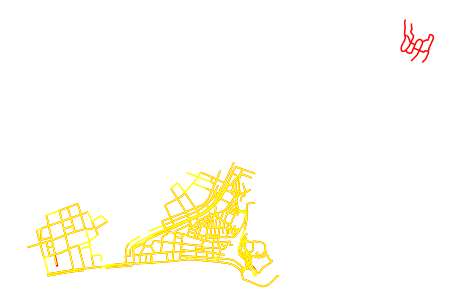

cremat
longueur 2888
in cc 1687


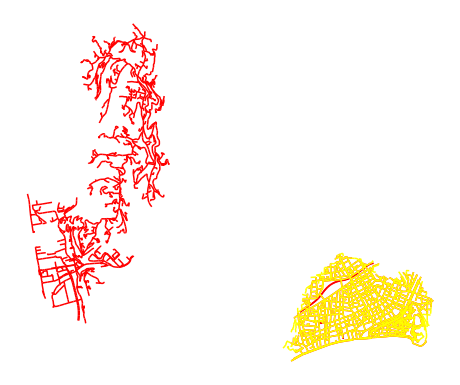

cyrille
longueur 296
in cc 253


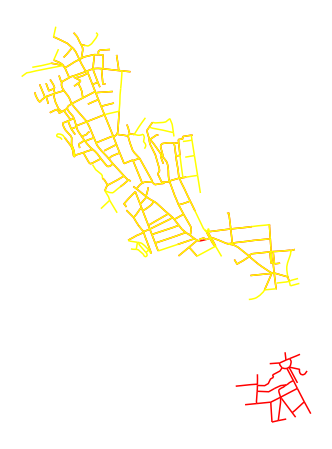

cyrille besset
longueur 232
in cc 214


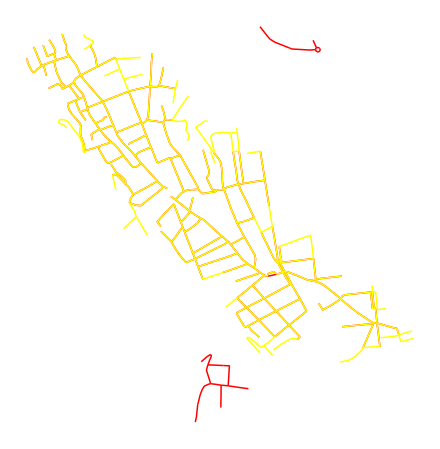

de
longueur 7538
in cc 6549


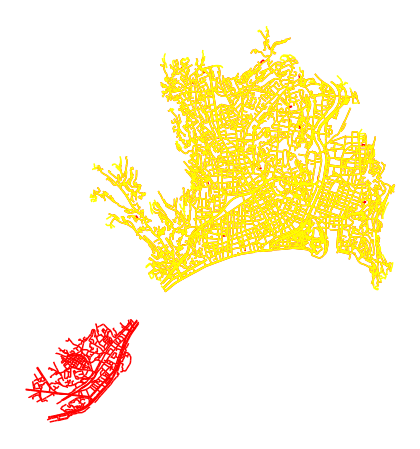

delfino
longueur 191
in cc 180


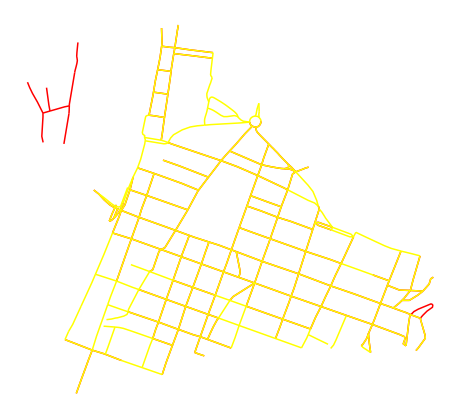

desambrois
longueur 115
in cc 113


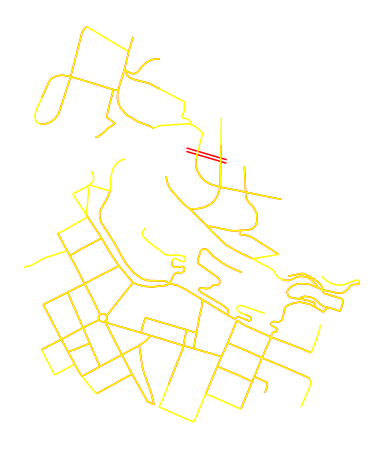

dubouchage
longueur 343
in cc 331


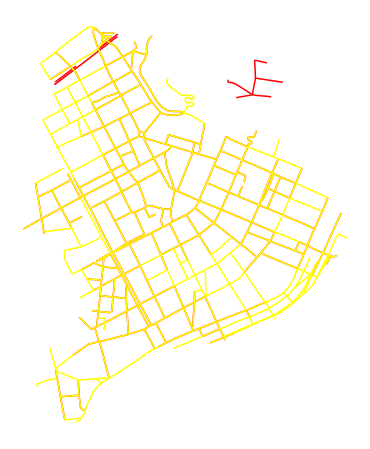

eco vallee
longueur 873
in cc 601


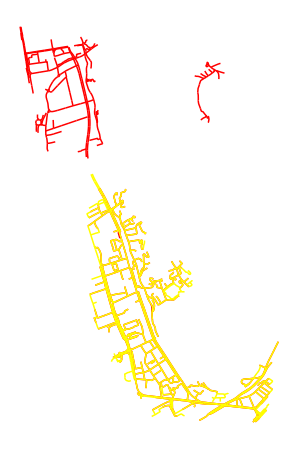

edhec
longueur 953
in cc 866


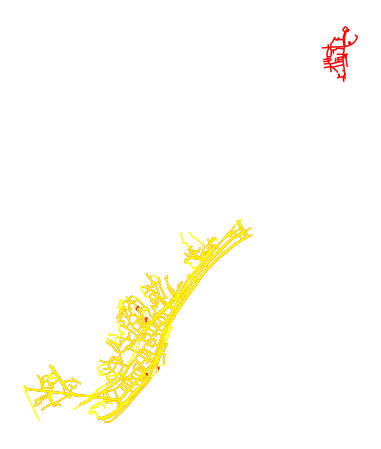

estienne orves
longueur 266
in cc 242


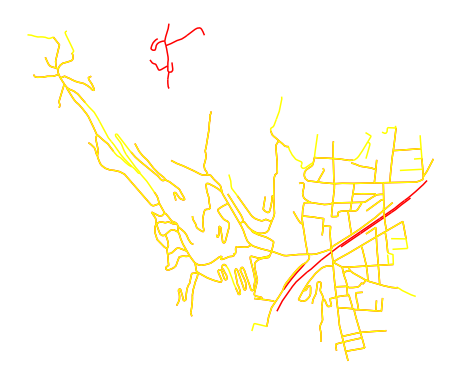

etoile
longueur 457
in cc 428


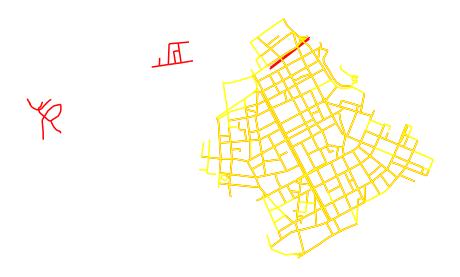

eveche
longueur 323
in cc 307


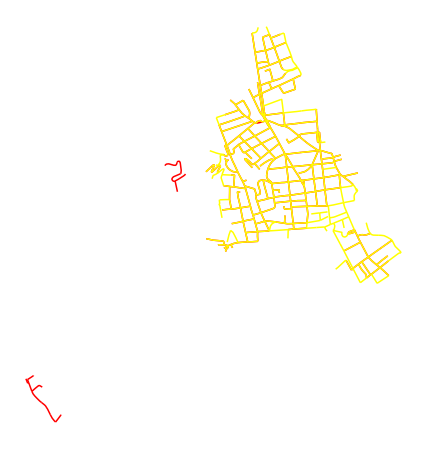

fabron
longueur 1070
in cc 899


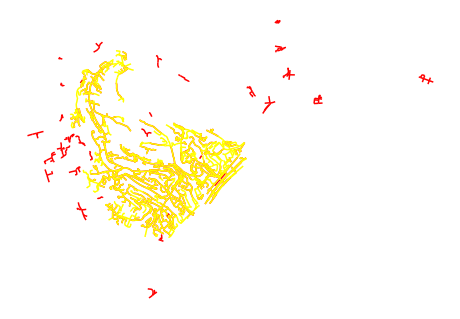

fac lettres
longueur 660
in cc 599


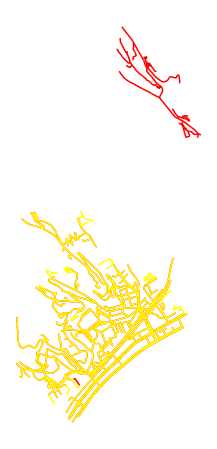

falicon
longueur 787
in cc 663


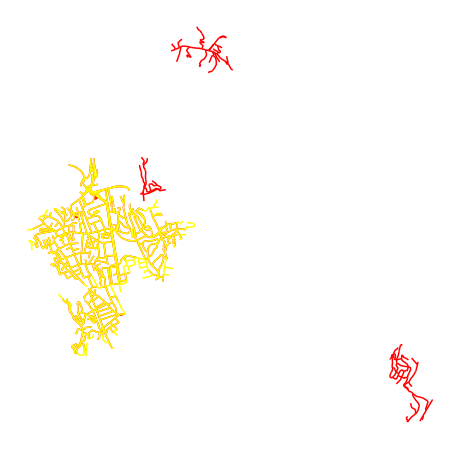

ferber
longueur 1000
in cc 586


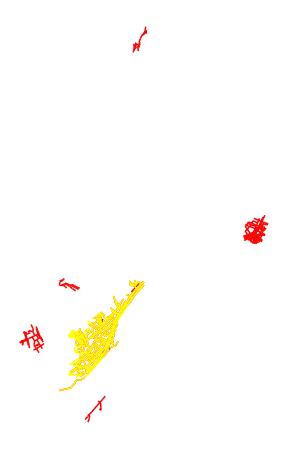

fleurie
longueur 521
in cc 367


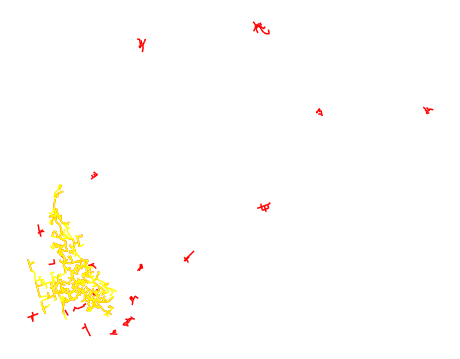

fleurs
longueur 601
in cc 487


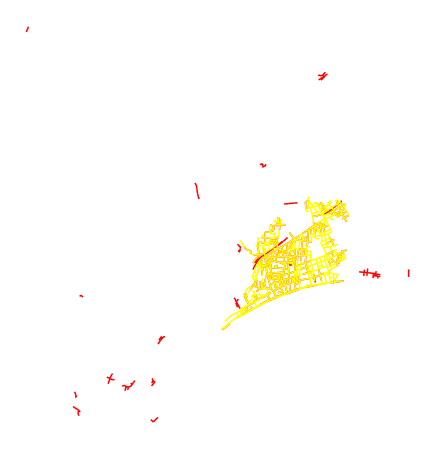

foch
longueur 340
in cc 304


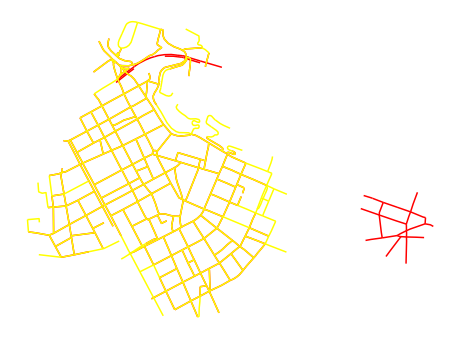

france
longueur 462
in cc 422


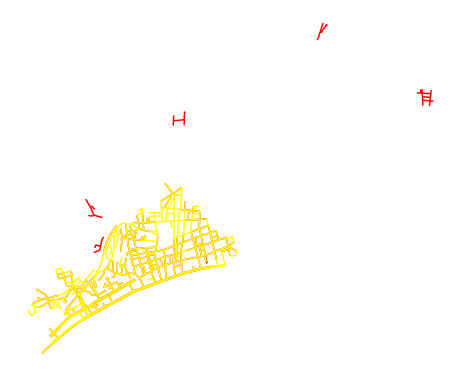

franck pilatte
longueur 111
in cc 103


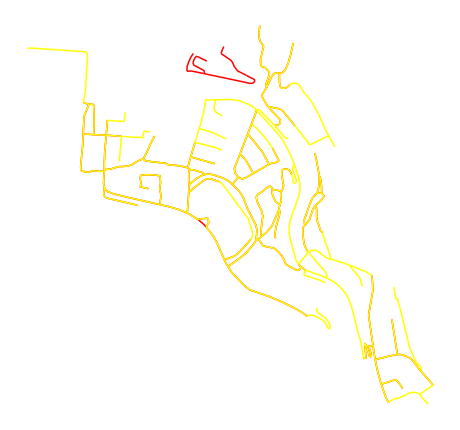

françois
longueur 1659
in cc 1462


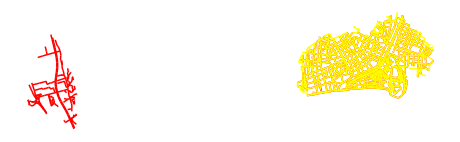

françois grosso
longueur 174
in cc 160


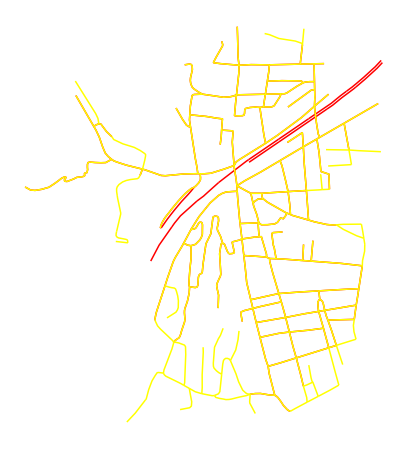

frederic passy
longueur 543
in cc 513


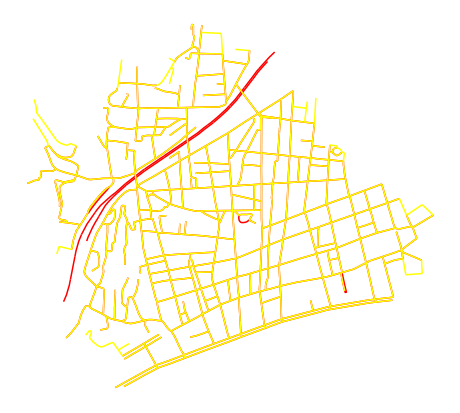

gairaut
longueur 1271
in cc 995


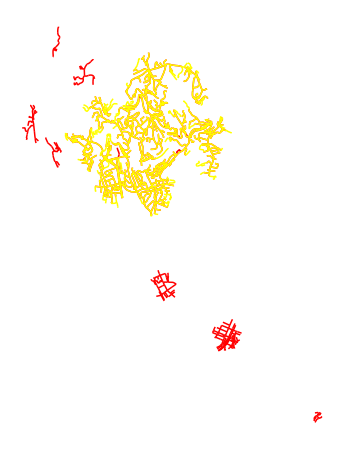

gambetta
longueur 959
in cc 840


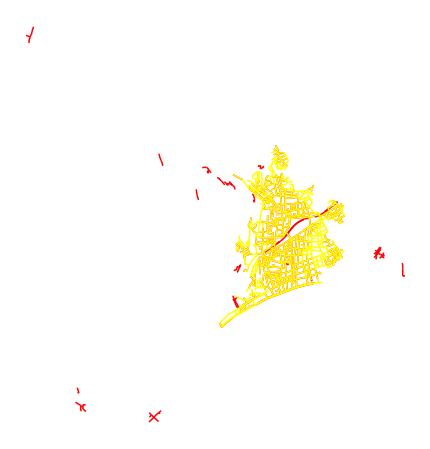

garibaldi
longueur 963
in cc 869


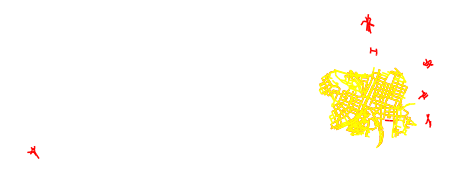

georges clemenceau
longueur 746
in cc 639


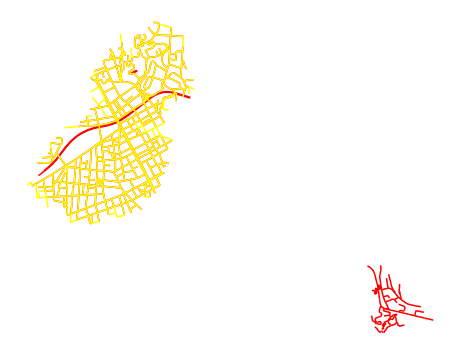

gioffredo
longueur 195
in cc 195


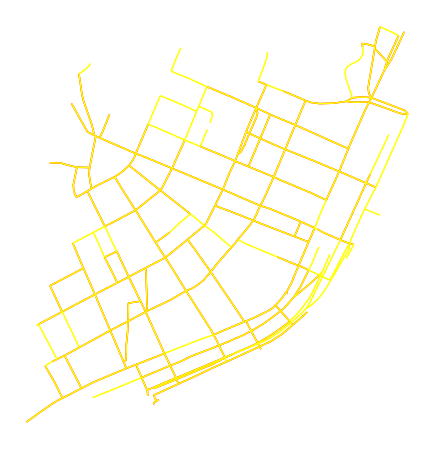

goiran
longueur 682
in cc 438


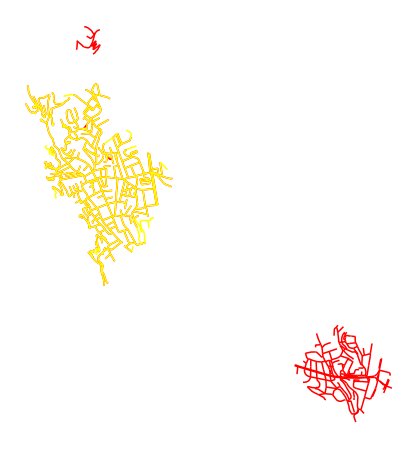

gorbella
longueur 669
in cc 639


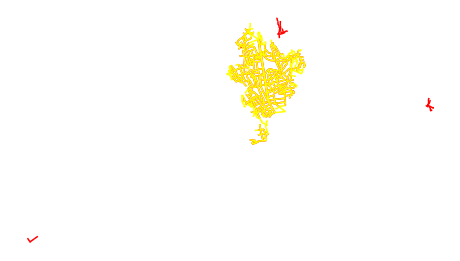

grande corniche
longueur 4269
in cc 3880


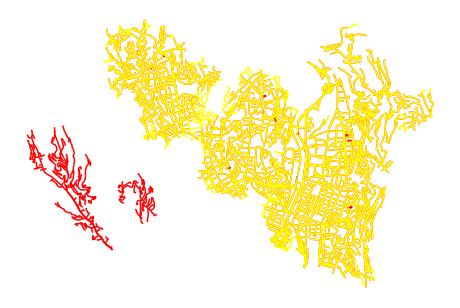

grosso
longueur 328
in cc 306


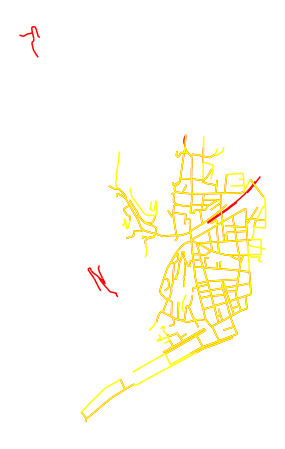

henri matisse
longueur 252
in cc 180


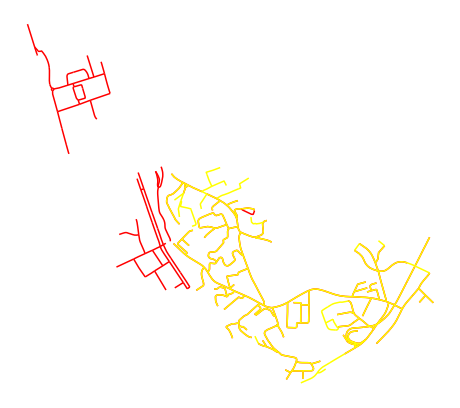

henri sappia
longueur 270
in cc 239


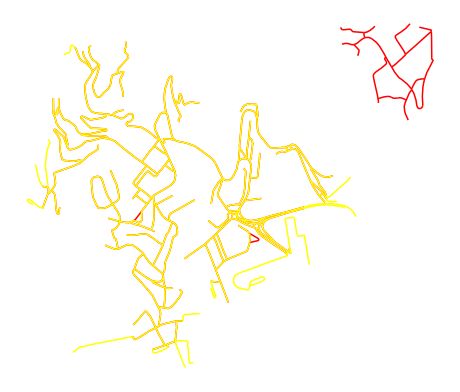

henry dunant
longueur 343
in cc 253


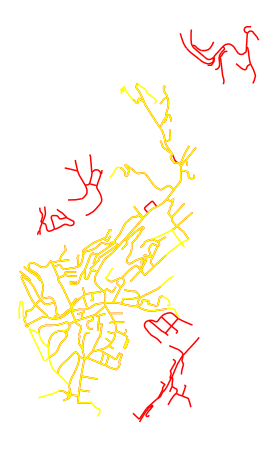

horloge
longueur 496
in cc 474


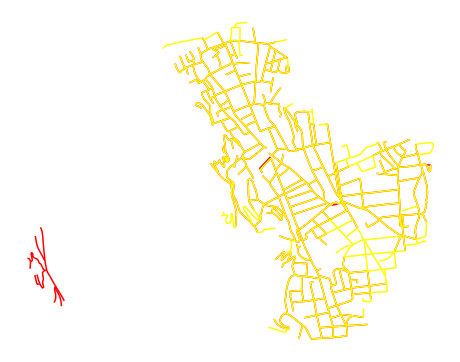

hyper
longueur 863
in cc 835


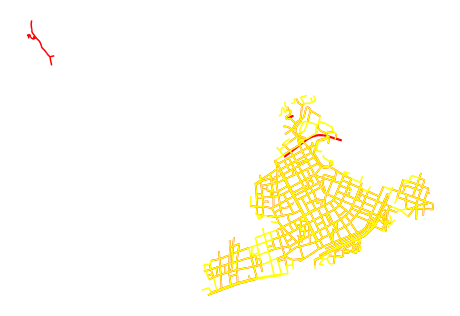

isidore
longueur 1268
in cc 506


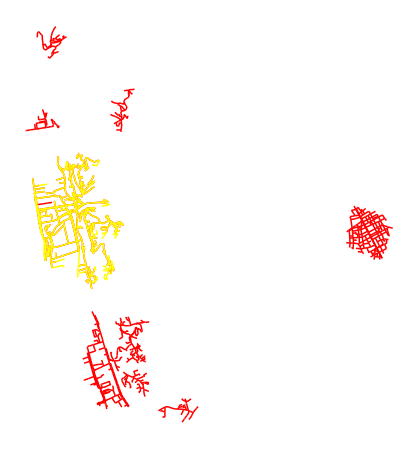

jean angely
longueur 774
in cc 642


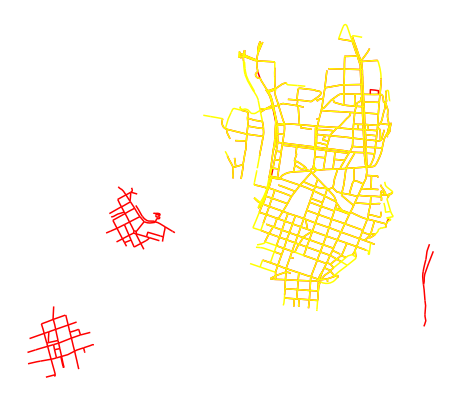

jean behra
longueur 218
in cc 212


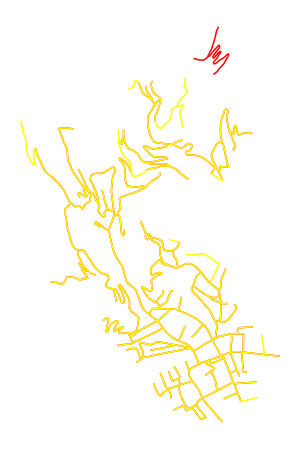

jean medecin
longueur 921
in cc 764


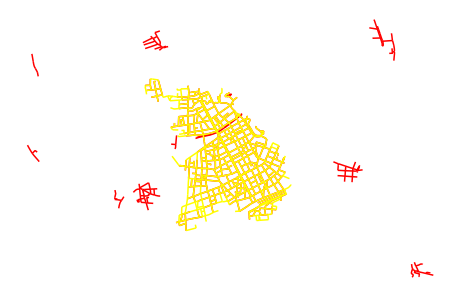

jeannet
longueur 8235
in cc 4253


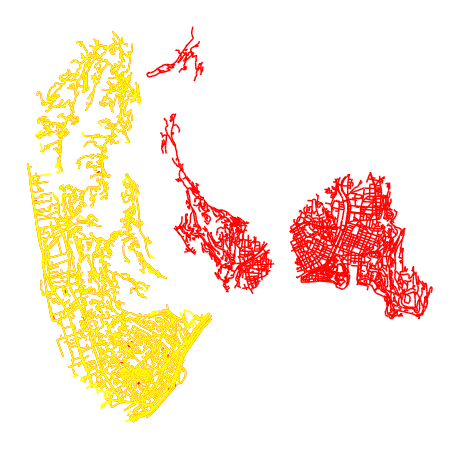

joseph garnier
longueur 256
in cc 256


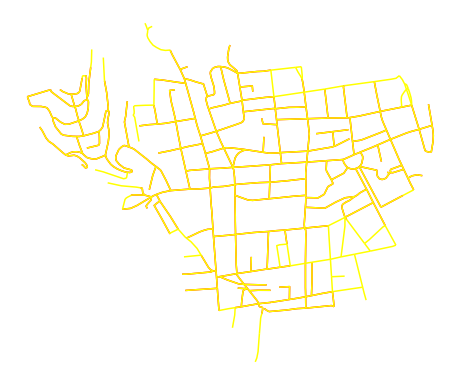

lanterne
longueur 538
in cc 397


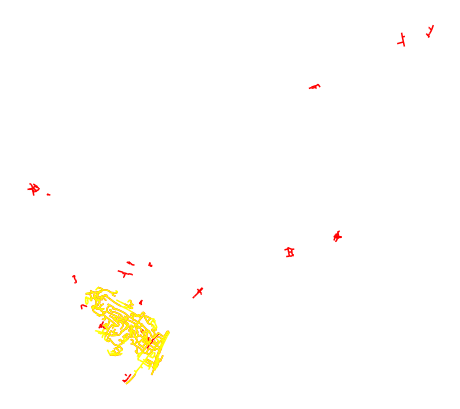

lepante
longueur 215
in cc 207


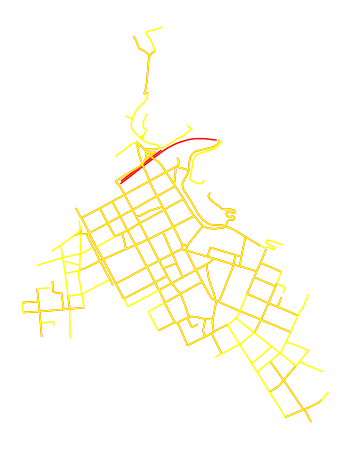

liberation
longueur 949
in cc 801


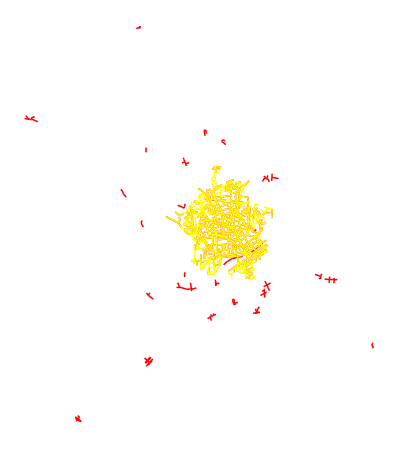

madeleine
longueur 648
in cc 429


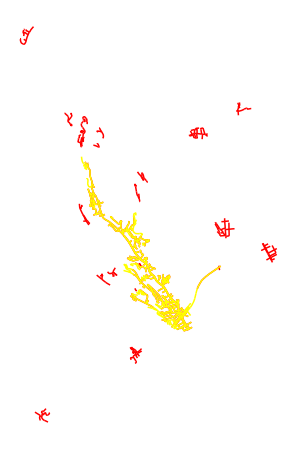

magnan
longueur 813
in cc 637


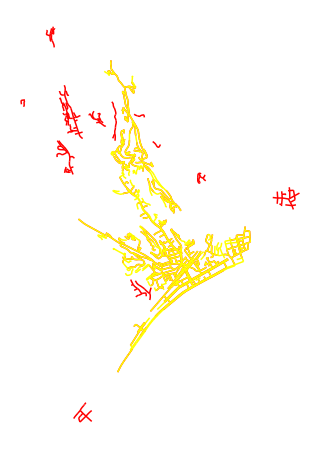

malaussena
longueur 166
in cc 147


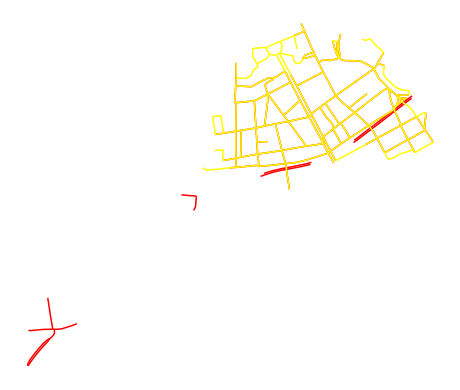

mantega
longueur 592
in cc 519


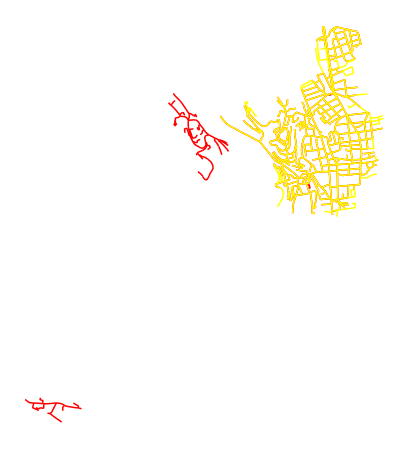

marceau
longueur 92
in cc 86


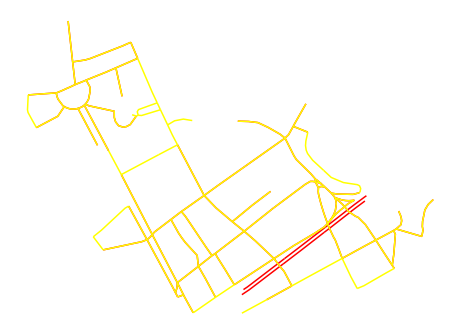

marguerite
longueur 975
in cc 444


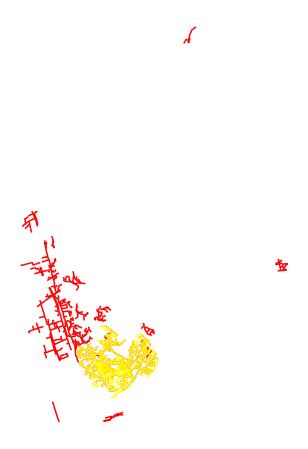

massena
longueur 1139
in cc 967


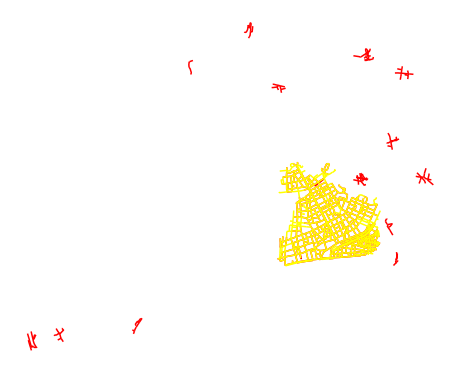

mathis
longueur 5871
in cc 5844


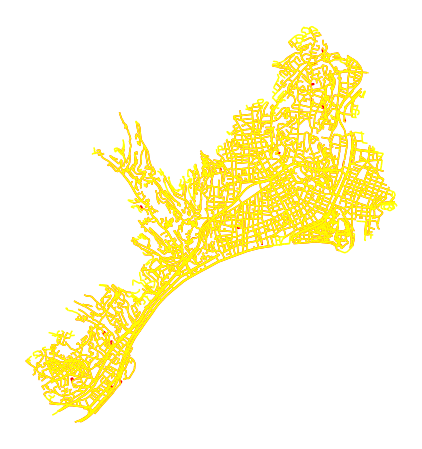

maurice
longueur 563
in cc 547


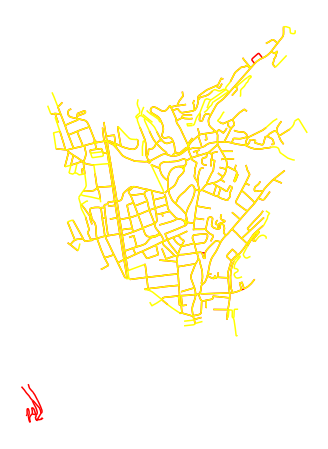

mediterranee
longueur 7527
in cc 6158


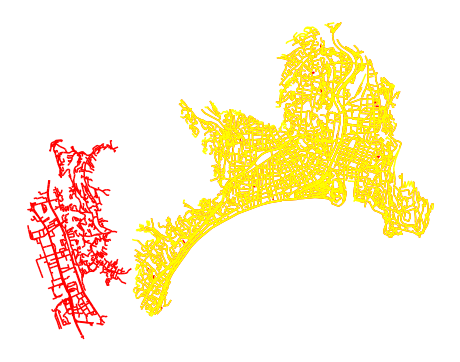

meridia
longueur 745
in cc 583


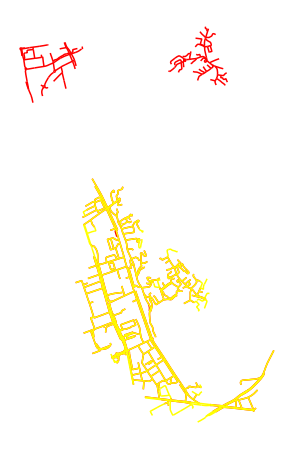

meyerbeer
longueur 420
in cc 385


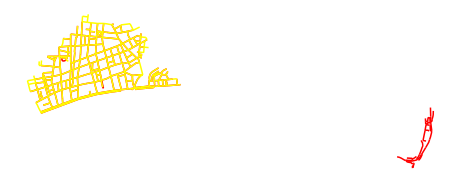

mirabeau
longueur 70
in cc 61


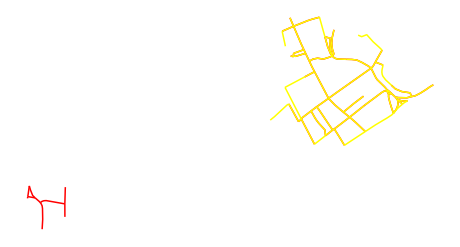

monaco
longueur 5587
in cc 4740


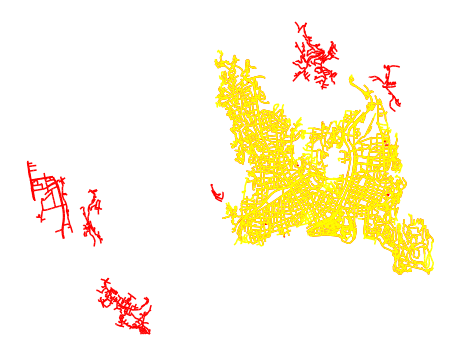

monastere
longueur 417
in cc 414


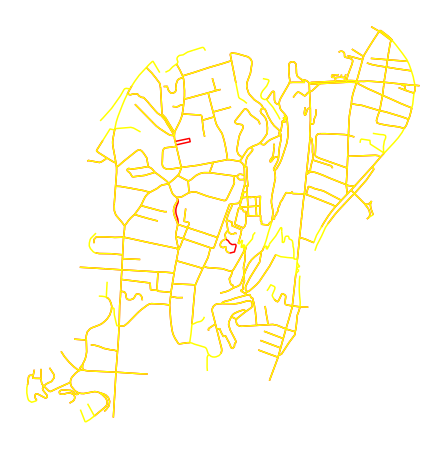

montreal
longueur 124
in cc 67


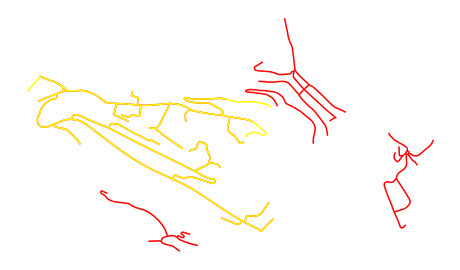

mozart
longueur 175
in cc 175


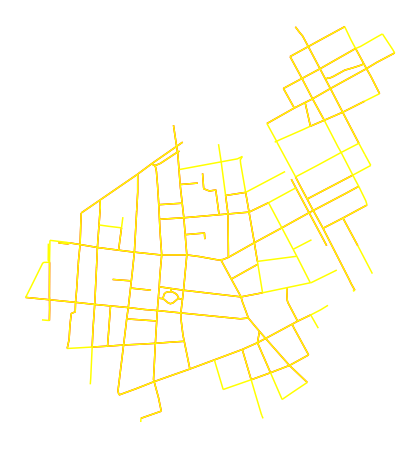

musicien
longueur 549
in cc 444


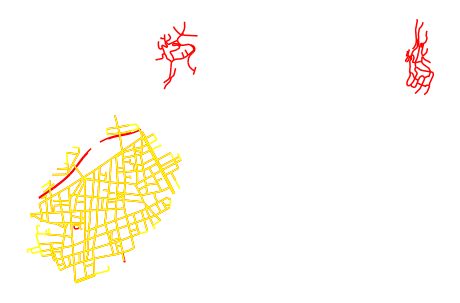

musiciens
longueur 377
in cc 315


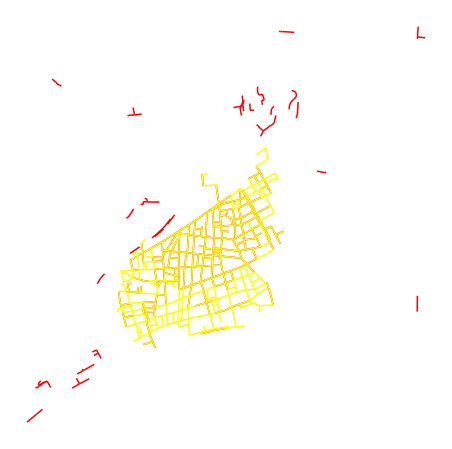

napoleon
longueur 714
in cc 648


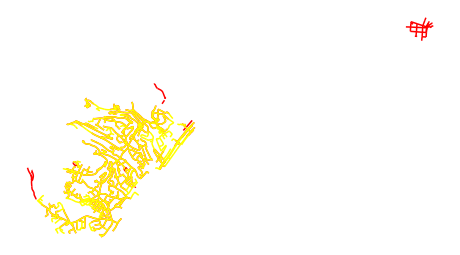

negresco
longueur 373
in cc 342


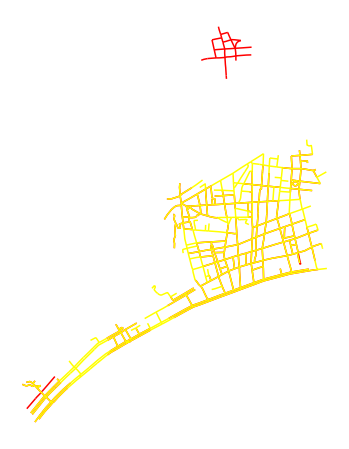

notre dame
longueur 518
in cc 491


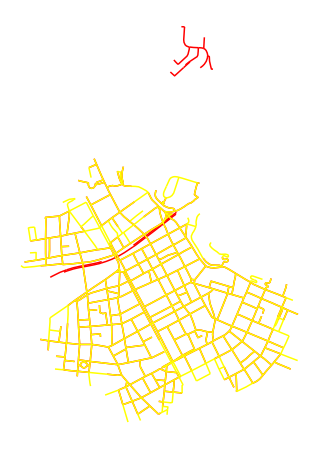

oliviers
longueur 1512
in cc 790


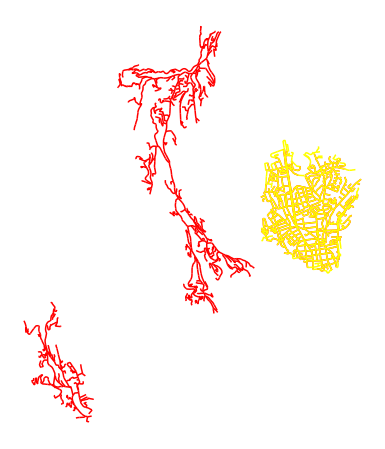

orangers
longueur 58
in cc 44


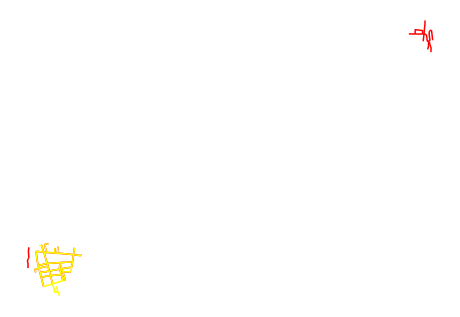

p
longueur 757
in cc 680


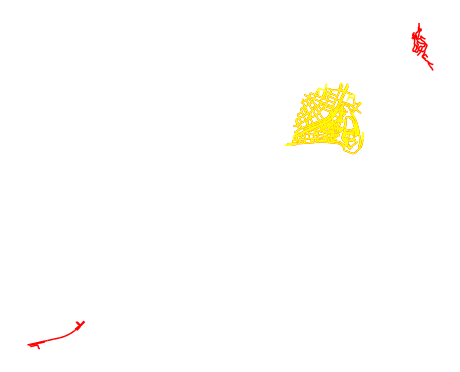

palais festival
longueur 4265
in cc 3901


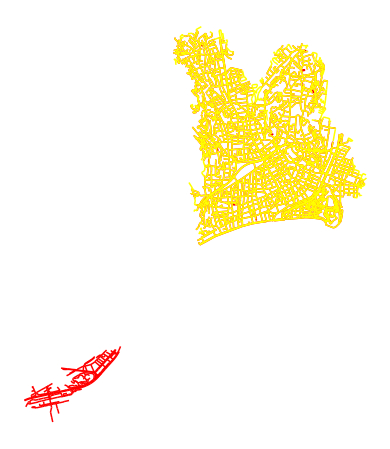

pancrace
longueur 1093
in cc 1055


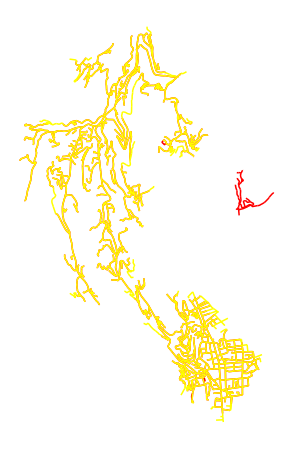

pasteur
longueur 561
in cc 394


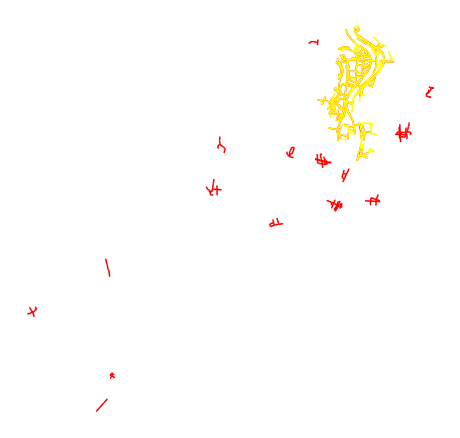

pastorelli
longueur 404
in cc 403


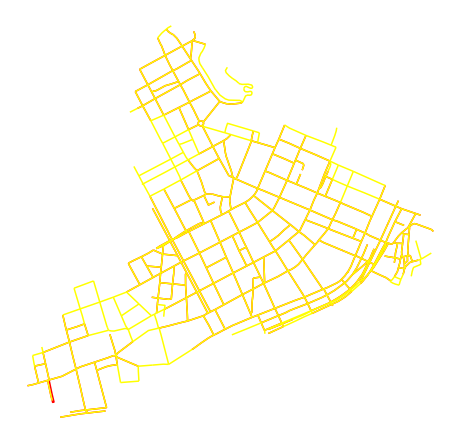

pessicart
longueur 814
in cc 677


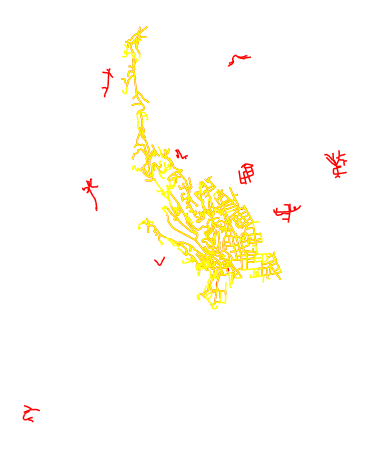

philippe
longueur 826
in cc 753


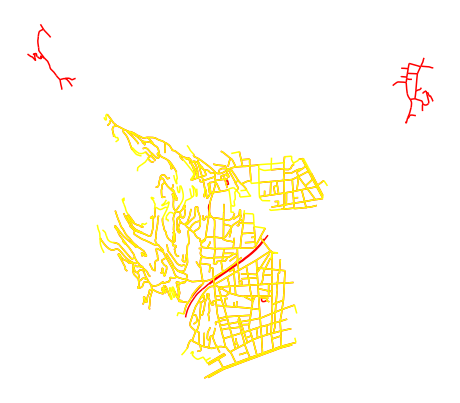

pierre feric
longueur 898
in cc 700


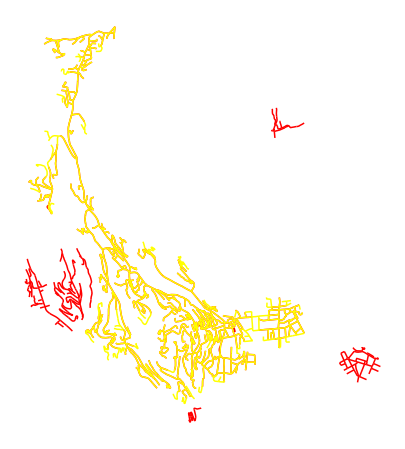

pietonne
longueur 324
in cc 303


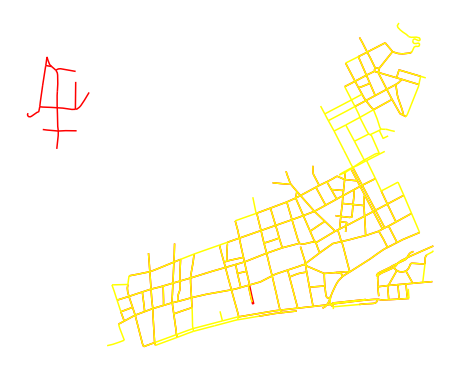

pignata
longueur 398
in cc 380


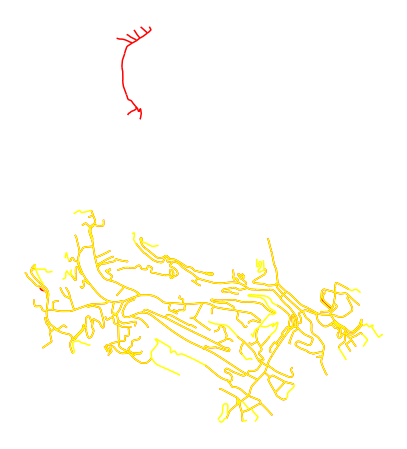

pin
longueur 567
in cc 550


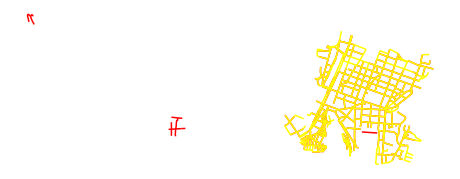

piol
longueur 954
in cc 820


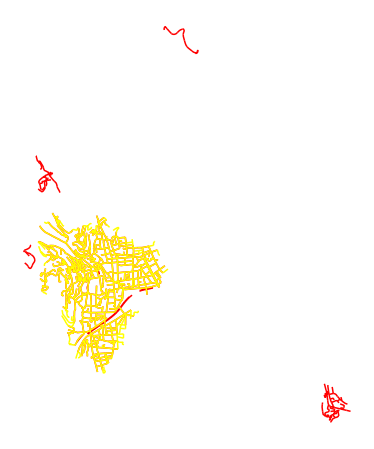

poetes
longueur 391
in cc 383


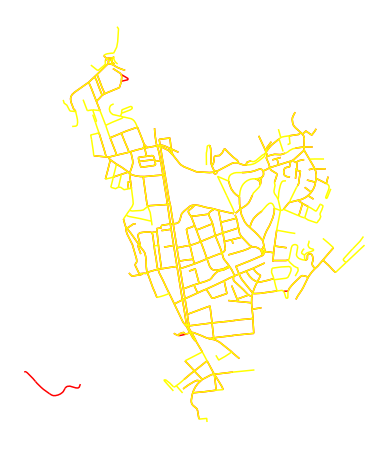

port
longueur 563
in cc 510


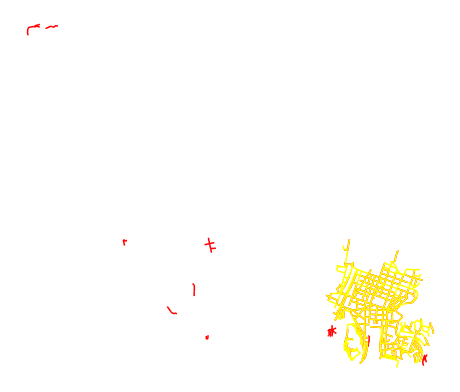

ray
longueur 639
in cc 622


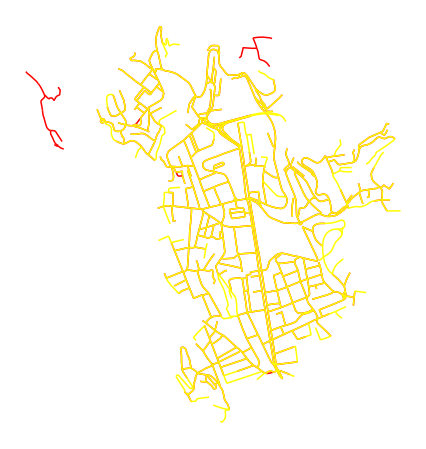

regina
longueur 1147
in cc 1141


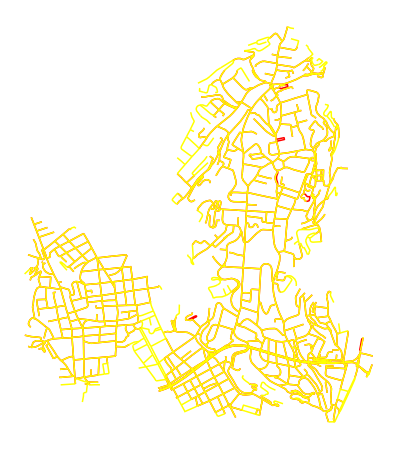

rene cassin
longueur 151
in cc 145


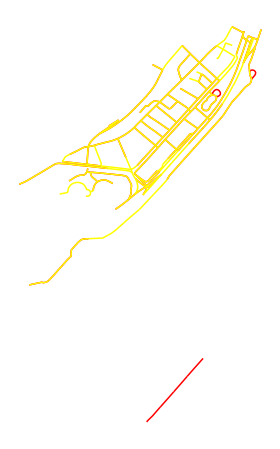

republique
longueur 315
in cc 284


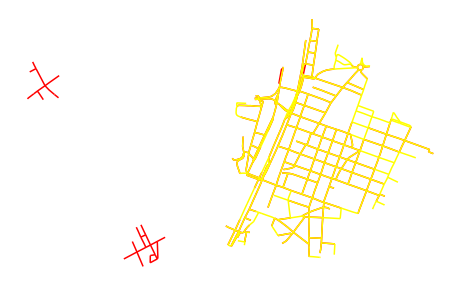

righi
longueur 126
in cc 126


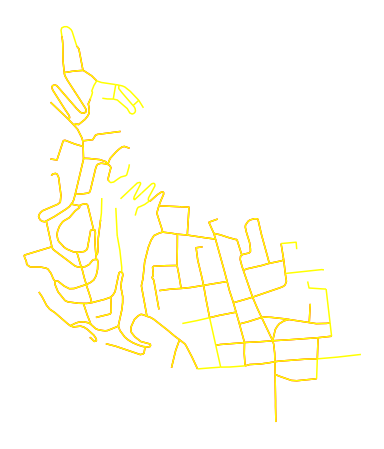

rimiez
longueur 1559
in cc 1088


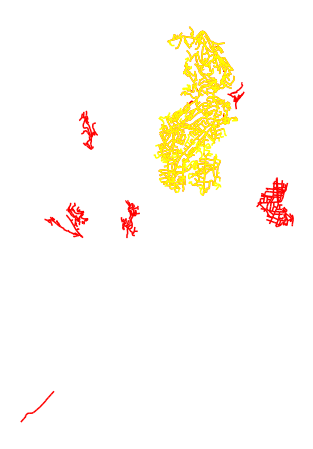

riquier
longueur 714
in cc 598


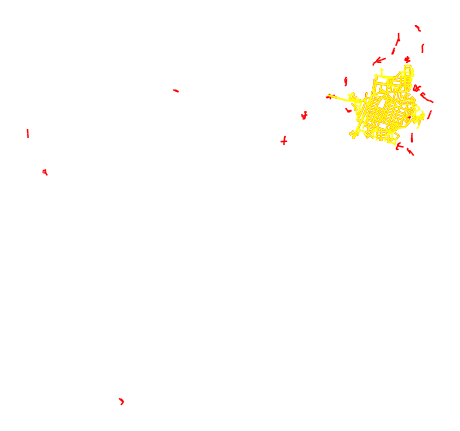

roch
longueur 589
in cc 478


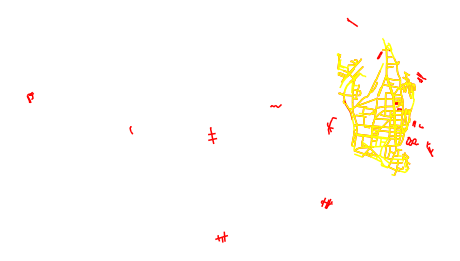

roman bellet
longueur 1226
in cc 631


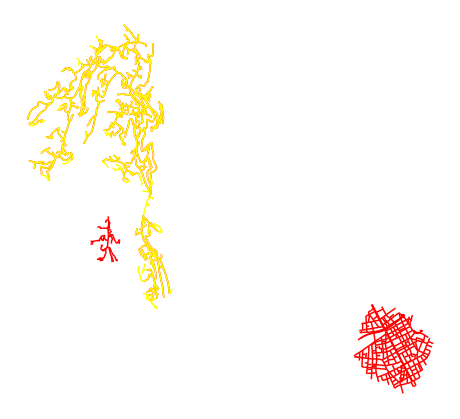

rossetti
longueur 270
in cc 259


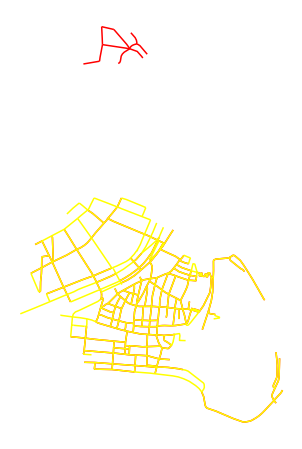

rossini
longueur 196
in cc 187


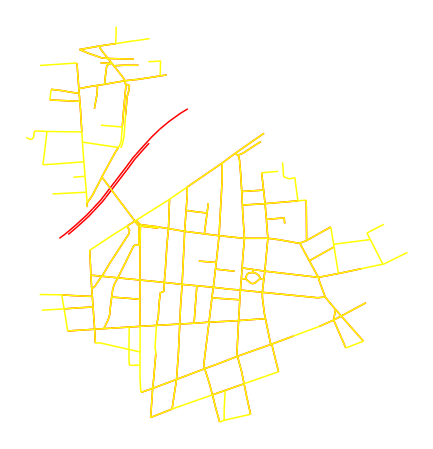

scuderi
longueur 122
in cc 119


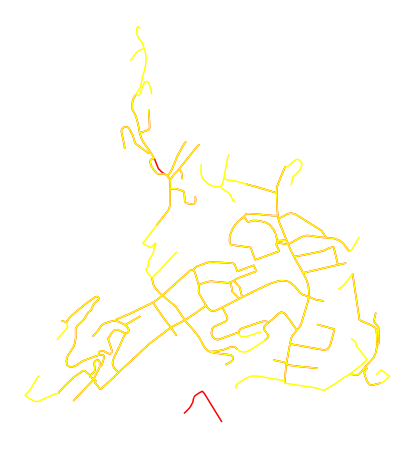

shakespeare
longueur 284
in cc 267


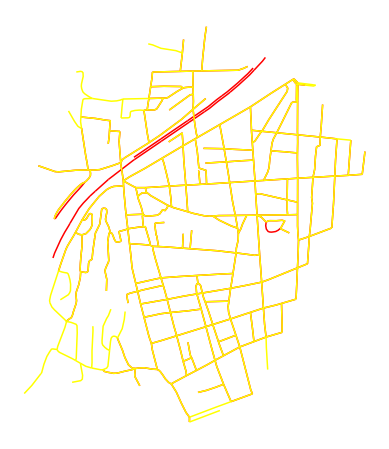

smolett
longueur 114
in cc 114


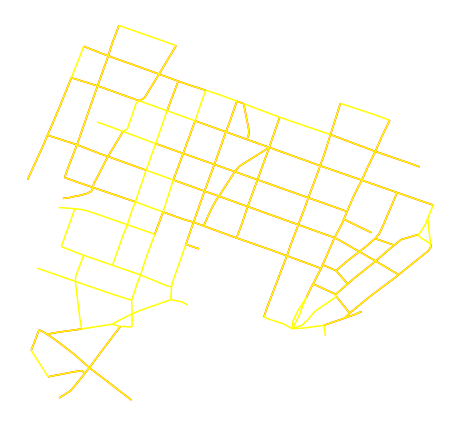

st
longueur 6993
in cc 6365


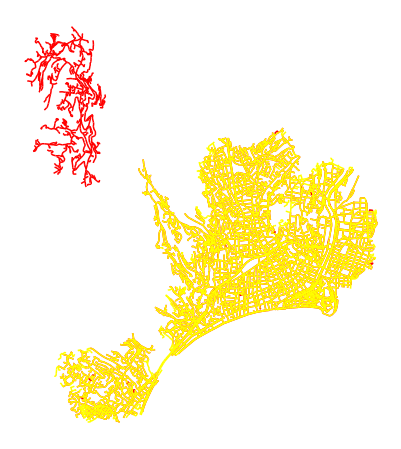

stalingrad
longueur 80
in cc 76


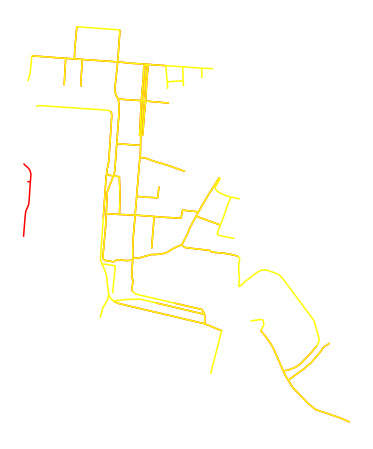

sylvestre
longueur 668
in cc 493


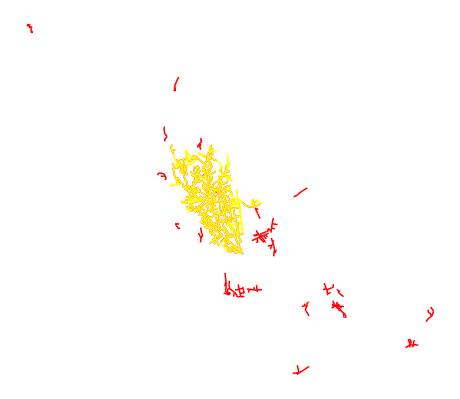

terron
longueur 300
in cc 259


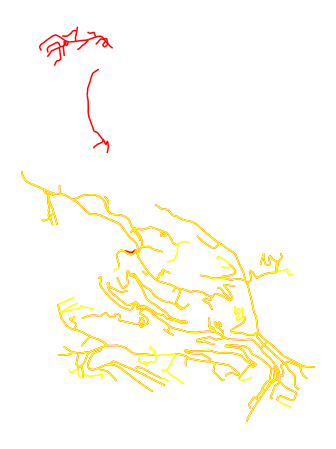

thiers
longueur 884
in cc 807


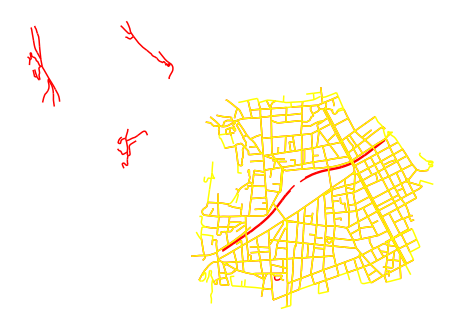

tnl
longueur 305
in cc 305


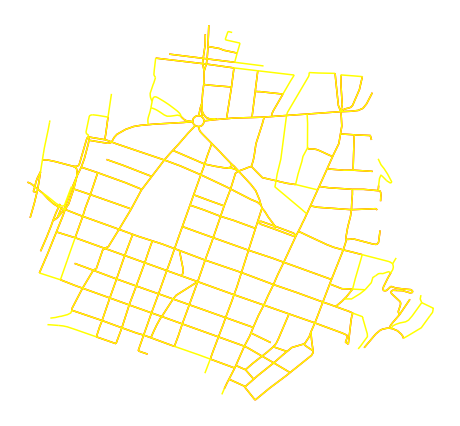

trachel
longueur 99
in cc 82


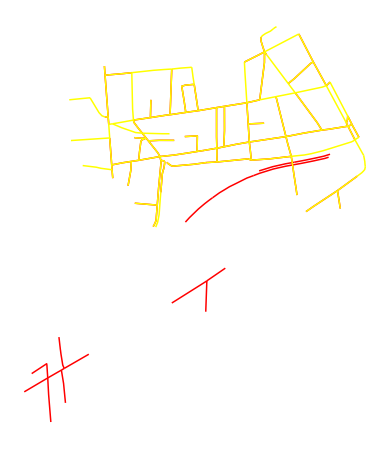

turin
longueur 689
in cc 595


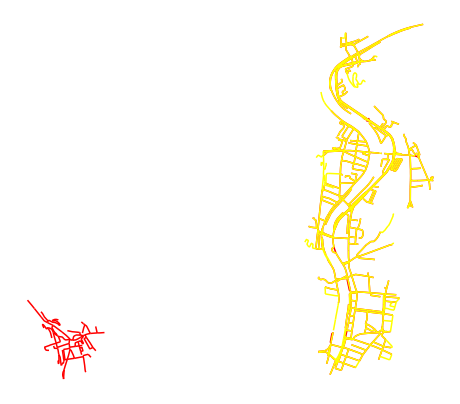

tzarewitch
longueur 80
in cc 73


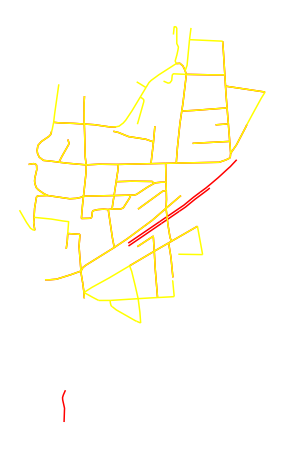

vallon barla
longueur 69
in cc 55


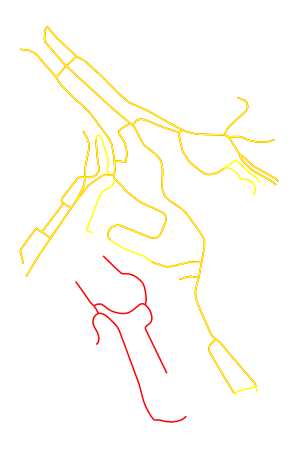

valrose
longueur 730
in cc 644


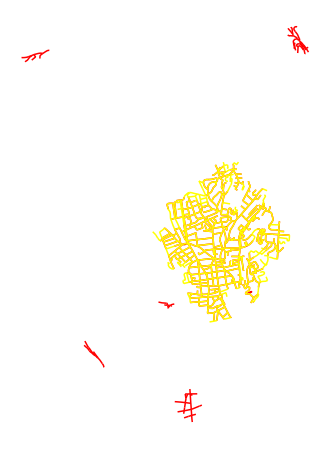

vauban
longueur 270
in cc 252


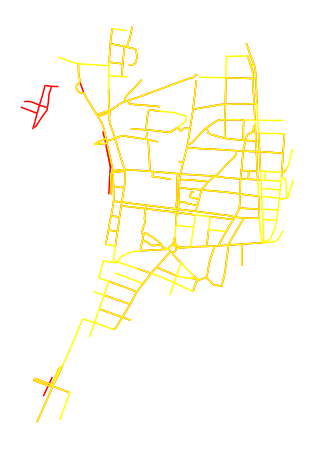

ventabrun
longueur 235
in cc 225


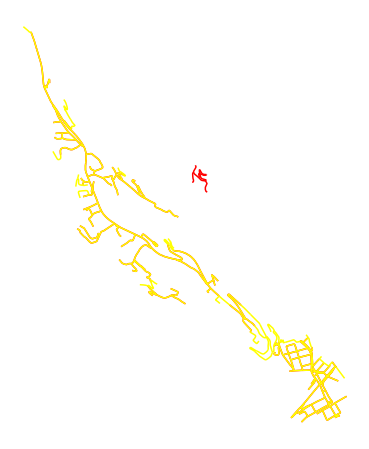

verdi
longueur 97
in cc 97


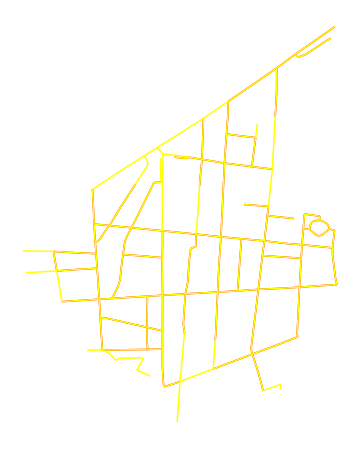

vernier
longueur 217
in cc 206


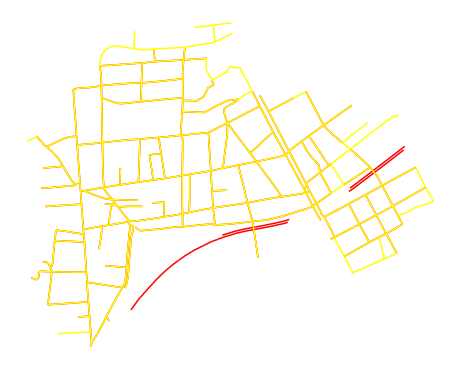

victor hugo
longueur 645
in cc 616


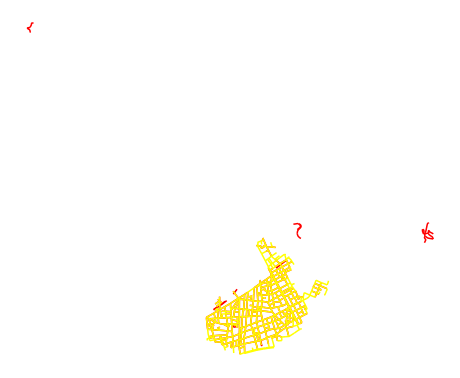

vieille ville
longueur 1268
in cc 1170


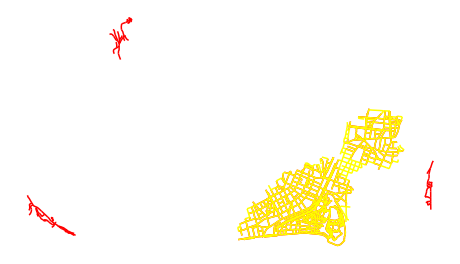

vieux
longueur 1821
in cc 1004


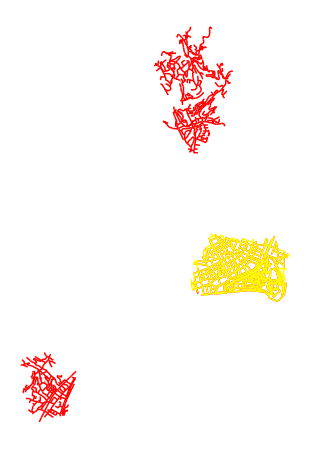

vieux nice
longueur 670
in cc 586


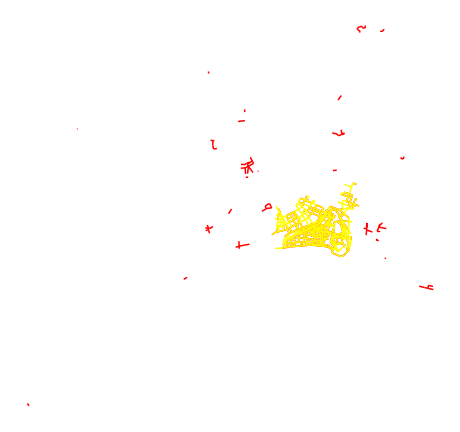

wilson
longueur 261
in cc 237


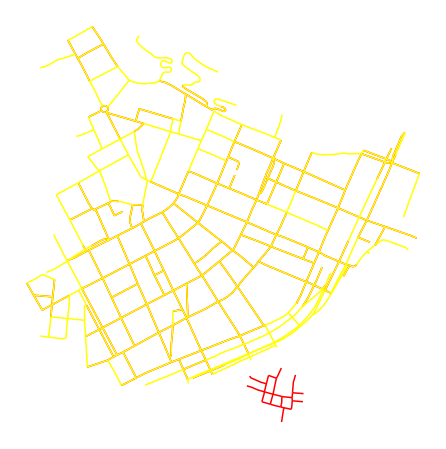

In [10]:
## PHENOME POSITIF 

for col_name in gdf.columns:
    
    # Exclure la colonne 
    if col_name not in notcol:
        print(col_name)
    
        # Extraire les identifiants dont les valeurs sont supérieures à 0
        gdf[col_name] = gdf[col_name].astype(float)
                
        ## SELECT INTERVAL ON LIXELS POSITIFS
        list_id_yes = list(set(list(gdf.loc[gdf[col_name] > ((gdf[col_name].max())/100) ].lineID)))
        ## DELATE LIXELS NOT IN INTERVALE 
        gdf[col_name] = gdf.apply(lambda x : x[col_name] if (x['lineID'] in list_id_yes) else 0, axis=1)
                       
        TOPONYM = gdf.loc[gdf[col_name] > 0.0]
        print("longueur", len(TOPONYM))
                
        G = momepy.gdf_to_nx(TOPONYM, approach='primal')
        
        G_dilated = dilatation_of_3(G_VILLE, G)
        G_eroded = erosion_of_3(G_VILLE, G_dilated)
        
                
        #Extraire première composante connexe
        largest_cc = max(nx.connected_components(G_eroded), key=len)
        CC = G_eroded.subgraph(largest_cc)
        CC1 = nx.Graph(CC)
                
        ## Noeuds et liens de la première CC
        subgraph_end_nodes, subgraph_end_edges = momepy.nx_to_gdf(CC1)
        
        # Retrieve the node identifiers of the Subgraph
        subgraph_edges_lineID = list(subgraph_end_edges["lineID"])
        len(subgraph_edges_lineID)
        gdf[col_name] = gdf.apply(lambda x: x[col_name] if x['lineID'] in subgraph_edges_lineID else 0, axis=1)
        print("in cc", len(gdf[gdf[col_name] > 0.0]))
        
                ##Plot
        f, ax = plt.subplots(figsize=(8,8))
        TOPONYM.plot(ax=ax, color='red', zorder=1) # INIT == VALEURS > 0.1
        subgraph_end_edges.plot(ax=ax, color='yellow', zorder=1) # INIT == VALEURS > 0.1
        ax.set_axis_off()
        plt.show()

In [26]:
path = gdf.to_csv("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/2_PHENOMENE_POSITIF_testofriquier.csv")

In [ ]:
path = gdf.to_csv("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/2_PHENOMENE_POSITIF.csv")

In [24]:
#file = open("MY_ADS_AFTER_00_CLEAN_0_0__working_df_1010.pickle", "rb")
path = "C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/2_PHENOMENE_POSITIF.pickle"
with open(path, 'wb') as f:
    pickle.dump(gdf, f)

path = gdf.to_csv("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/2_PHENOMENE_POSITIF.csv")

    # EXTRAIRE LES ANNONCES DANS LE PHENOMENE QUI NE PARLENT PAS DU PHENOMENE A TRAVERS UNE NOTION DE SITUATION (>> Netkde négatif)

In [25]:
file = open("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/2_PHENOMENE_POSITIF.pickle", "rb")
gdf = pickle.load(file)
file.close()

In [13]:
ADS_AM= ADS_AM.to_crs(epsg=2154)

DICT = {}
for col_name in gdf.columns:
    
    # Exclure la colonne 
    if col_name not in notcol:
        print(col_name)
        
        TOPONYM = gdf.loc[gdf[col_name] > 0.0] #.unary_union
        # Fusion des lignes de la même composante connexe
        G = momepy.gdf_to_nx(TOPONYM, approach='primal')
        TOPONYM_edges = [G.edges[edge]['geometry'] for edge in G.edges]
        TOPONYM_edges_merged_lines = linemerge(TOPONYM_edges)
        #TOPONYM_BUFFER = TOPONYM_edges_merged_lines.buffer(2) 
        TOPONYM_BUFFER = TOPONYM_edges_merged_lines.buffer(500) ################ SELECT IF MORE 
        #type(TOPONYM_BUFFER)
        #print('buff')
        t = gpd.GeoDataFrame(index=[0], crs='epsg:2154', geometry=[TOPONYM_BUFFER])
        test = ADS_AM.loc[ADS_AM.within(t.loc[0,'geometry'])]
        print("longueur intersect",len(test))
        

            ## V1 CHOOSE NNONLY WHERE TOPO_3 == TOPONYME
        ADS_WANT =  test.loc[test['new_cat_rs'] == "IN"] #Choose knowledges = IN
        #len(ADS_WANT)
        ADS_WANT_YES =  ADS_WANT.loc[ADS_WANT['topo_3'] == col_name]
        #print(len(ADS_WANT_YES))
        list_index_yes = list(set(list(ADS_WANT_YES['idAnnonce'])))
        #print(len(list_index_yes))
        ADS_WANT_NO = ADS_WANT.loc[ADS_WANT['topo_3'] != col_name] 
        #len(ADS_WANT_NO)
        ADS_WANT_NO = ADS_WANT_NO[~ADS_WANT_NO['idAnnonce'].isin(list_index_yes)]
        #len(ADS_WANT_NO)
        list_index_no = list(set(list(ADS_WANT_NO['idAnnonce'])))
        print(len(list_index_no))
        
        



        
        
        
           ## V2 CHOOSE NNONlY WITH REGEX
        #ADS_WANT =  test.loc[test['cat_rs'] == "IN"] #Choose knowledges = IN
        #ADS_WANT = ADS_WANT.drop_duplicates(subset=['idAnnonce'])
        #ADS_WANT = ADS_WANT[~ADS_WANT.DESCRIPTION.str.contains(col_name, regex= True, na=False)]
        #list_index_no = list(set(list(ADS_WANT['idAnnonce'])))


        DICT[col_name] = list_index_no
        print("ok", len(DICT))

acropolis


KeyboardInterrupt: 

    #    # save as Dictionnaire  ## Dictionnaire avec comme clés : les toponymes étudiés et en valeur : liste des annonces idAnnonce concernées sur lesquelles appliquer le kde
    
with open('DICT_of_toponym_intersected.pickle', 'wb') as f:
    pickle.dump(DICT, f)


In [27]:
with open("C:/GIT/2022/TOPONOMASCAPE/VILLE/"+VILLE+"/dict_ads_negatives.json", 'w') as fp:
    json.dump(DICT, fp)